# Construction de Portefeuille 
## Strategie Black-Litterman avec Views ESG Dynamiques et Validation Walk-Forward

---

### Contexte et positionnement du projet

Ce notebook constitue un projet de construction de portefeuille dans le cadre de la finance socialement responsable. Il s'inscrit dans une demarche d'investissement qui vise a reconcilier performance financiere et durabilite extra-financiere, en repondant a deux exigences simultanees : respecter des contraintes reglementaires strictes de screening ESG, et maximiser le profil rendement-risque du portefeuille au sens de Markowitz.

La strategie retenue est le modele de **Black-Litterman (1990, 1992)**, l'un des cadres les plus solides et les plus utilises en gestion quantitative institutionnelle. Ce modele resout un probleme fondamental de l'optimisation classique : les poids issus d'une optimisation moyenne-variance pure sont hypersensibles aux erreurs d'estimation des rendements attendus, ce qui produit des portefeuilles concentres et instables dans le temps. Black-Litterman corrige cela en combinant un prior de marche bien defini — les rendements d'equilibre implicites du CAPM — avec les convictions propres du gestionnaire, exprimees sous forme de "views". Dans notre strategie, ces views sont directement derives des **scores ESG des entreprises**, ce qui constitue l'innovation centrale du projet.

### Apport  : vers un modele pleinement dynamique

**1. Validation walk-forward rigoureuse :** a chaque date de rebalancement mensuel, le portefeuille est reconstruit uniquement avec les donnees disponibles a cette date. La performance est evaluee sur le mois suivant, strictement hors echantillon. Ce protocole elimine tout biais de lookahead et produit des resultats directement comparables a une mise en production reelle.

**2. Modele BL dynamique :** deux ameliorations rendent les views adaptatives a chaque rebalancement. L'alpha est desormais calibre sur la dispersion historique observee des rendements, ce qui rend l'intensite des views proportionnelle au regime de marche courant. Par ailleurs, un signal de momentum ESG sur 6 mois est integre dans les views composites : un titre dont le score s'ameliore recoit une conviction superieure a son equilibre de marche, un titre en degradation est penalise.

### Structure du notebook

```
Section 1 : Chargement des donnees et configuration
Section 2 : Analyse statistique de l'univers avant screening
Section 3 : Application des filtres reglementaires obligatoires
Section 4 : Mesure de l'impact du screening (avant / apres)
Section 5 : Pipeline Black-Litterman dynamique (definition)
Section 6 : Construction du portefeuille final et benchmarks
Section 7 : Validation walk-forward mensuelle (anti-lookahead)
Section 8 : Analyse des resultats et rapport final
```

## Section 1 — Imports, Configuration et Parametres de la Strategie

Cette cellule centralise l'ensemble des parametres de la strategie. Ce choix de conception est delibere : regrouper tous les hyperparametres en un seul endroit permet de modifier la strategie sans intervenir dans le corps du code, ce qui est une pratique standard en gestion quantitative pour garantir la reproductibilite et faciliter l'analyse de sensibilite.

Les parametres cles sont les suivants :

- **JOURS_TRADING = 252** : convention de marche pour l'annualisation des rendements et des volatilites. Le nombre de jours de cotation effectifs par an est de 252 pour les marches actions dans les pays developpes.

- **TAUX_SANS_RISQUE = 0.03** : taux d'actualisation de reference utilise dans le calcul du ratio de Sharpe. Il est approxime par le taux de l'OAT 10 ans France, qui represente le cout d'opportunite d'un investissement sans risque dans la zone euro.

- **DELTA = 2.5** : coefficient d'aversion au risque implicite du marche dans le modele CAPM. Ce parametre est standard dans la litterature Black-Litterman. Il correspond approximativement au rapport rendement/variance du portefeuille de marche observe historiquement.

- **ALPHA = ? : ce parametre devient dynamique et est recalibre a chaque rebalancement (cf. Section 5).

- **W_STATIQUE = 0.70 et W_MOMENTUM = 0.30** : poids respectifs du score ESG courant et du momentum ESG dans la view composite. La predominance du score statique (70%) ancre les views dans la notation fondamentale, tandis que le momentum (30%) capte la dimension temporelle de l'amelioration extra-financiere.

In [ ]:
# ETHICS — Ethical Investing with the Black-Litterman Model
# Notebook de recherche et de développement pour une strategie d'investissement responsable
# basée sur le modele de Black-Litterman et des indicateurs ESG.

# SECTION 1 — IMPORTS ET CONFIGURATION GENERALE
#
# Les librairies sont organisees par famille fonctionnelle :
# - pandas / numpy : manipulation des series temporelles et calcul matriciel
# - matplotlib : visualisation des distributions, performances et allocations
# - scipy.optimize : optimisation non-convexe sous contraintes (SLSQP)
# - sklearn.covariance : estimateur de Ledoit-Wolf pour la matrice de covariance
#
# Les parametres globaux de la strategie sont concentres ici pour faciliter
# l'analyse de sensibilite et garantir la reproductibilite des resultats.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
from sklearn.covariance import LedoitWolf

# Configuration de l'affichage
pd.set_option('display.max_columns', 20)

pd.set_option('display.width', 120)

pd.set_option('display.float_format', '{:.4f}'.format)

# Configuration des graphiques
plt.rcParams['figure.figsize'] = (14, 7)

plt.rcParams['font.size'] = 11

plt.rcParams['axes.grid'] = True

plt.rcParams['grid.alpha'] = 0.3

# Chemin vers le repertoire des fichiers Parquet
# Modifier uniquement cette variable pour adapter le notebook a un autre environnement

PATH = "C:/Users/koffi/Downloads/Portfolio_esg/Ethics_data/data/"

# Parametres financiers de la strategie
# JOURS_TRADING : convention standard pour l'annualisation (marches actions OCDE)
# TAUX_SANS_RISQUE : OAT 10 ans France — cout d'opportunite de reference dans la zone euro
# DELTA : aversion au risque implicite du marche (He & Litterman 1999)
# ALPHA : intensite initiale des views ESG — sera calibre dynamiquement en Section 5

JOURS_TRADING = 252
TAUX_SANS_RISQUE = 0.03
DELTA = 2.5
ALPHA = 0.03



Toutes les librairies importées avec succès.
 NumPy version : 2.4.3
 Pandas version : 3.0.1


## Section 2.1 — Chargement des Donnees Sources

Cinq fichiers au format Parquet constituent la base de donnees du projet. Le format Parquet est prefere au CSV pour sa compression efficace et la preservation des types de donnees, notamment les index temporels.

- **metadata.parquet** : referentiel statique des entreprises. Contient l'identifiant, le nom, le pays et le secteur d'activite. Ce fichier sert de table de jointure pour toutes les analyses sectorielles.

- **esg_score.parquet** : historique des scores ESG par entreprise. Format large (dates en lignes, tickers en colonnes). Les scores ESG sont produits par un fournisseur de donnees extra-financieres et aggregent trois dimensions : environnementale (E), sociale (S) et de gouvernance (G). L'historique temporel est essentiel pour le calcul du momentum ESG dans les views dynamiques.

- **itr.parquet** : Implied Temperature Rise par entreprise. L'ITR est une metrique climatique qui exprime, en degres Celsius, le rechauffement global qui resulterait si toutes les entreprises du monde avaient la meme trajectoire d'emissions que le titre analyse. Un ITR inferieur ou egal a 2 degres C signifie que l'entreprise est alignee avec l'Accord de Paris (2015).

- **universe.parquet** : indicateur binaire (0/1) signalant si une entreprise appartient a l'univers investissable officiel a une date donnee. Permet de gerer les entrees et sorties de l'univers dans le temps.

- **price.parquet** : historique des prix de cloture ajustes (dividendes, splits). Ces prix sont utilises pour calculer les rendements logarithmiques, estimer la matrice de covariance et evaluer les performances du portefeuille.

In [ ]:

# SECTION 2.1 — CHARGEMENT DES DONNEES SOURCES
#
# Les cinq fichiers sont charges et leur index temporel est converti en
# DatetimeIndex trie chronologiquement. Ce tri est indispensable pour toutes
# les operations de slicing temporel ulterieures (loc[:date], iloc[-1], etc.).
#
# Les tables de lookup (sector_map, name_map) sont pre-construites pour eviter
# des jointures repetees dans la boucle de rebalancement walk-forward.


metadata = pd.read_parquet(PATH + 'metadata.parquet', engine='pyarrow')
print(f" Metadata : {metadata.shape[0]} entreprises, {metadata.shape[1]} attributs")

esg_raw = pd.read_parquet(PATH + 'esg_score.parquet', engine='pyarrow')

esg_raw.index = pd.to_datetime(esg_raw.index)

esg_raw = esg_raw.sort_index()

print(f" ESG Score : {esg_raw.shape[0]} dates, {esg_raw.shape[1]} tickers")

print(f" Période : {esg_raw.index.min().date()} - {esg_raw.index.max().date()}")

itr_raw = pd.read_parquet(PATH + 'itr.parquet', engine='pyarrow')

itr_raw.index = pd.to_datetime(itr_raw.index)

itr_raw = itr_raw.sort_index()

print(f" ITR : {itr_raw.shape[0]} dates, {itr_raw.shape[1]} tickers")



universe_raw = pd.read_parquet(PATH + 'universe.parquet', engine='pyarrow')

universe_raw.index = pd.to_datetime(universe_raw.index)

universe_raw = universe_raw.sort_index()

print(f" Universe : {universe_raw.shape[0]} dates, {universe_raw.shape[1]} tickers")

price_raw = pd.read_parquet(PATH + 'price.parquet')
price_raw.index = pd.to_datetime(price_raw.index)
price_raw = price_raw.sort_index()

print(f" Prices : {price_raw.shape[0]} dates, {price_raw.shape[1]} tickers")
print(f" Période : {price_raw.index.min().date()} - {price_raw.index.max().date()}")

# Tables de lookup construites une seule fois pour accelerer la boucle rolling

sector_map = metadata.set_index('ID')['SECTOR'].to_dict()
name_map = metadata.set_index('ID')['NAME'].to_dict()

Chargement des données...
 Metadata : 269 entreprises, 15 attributs
 ESG Score : 18 dates, 269 tickers
 Période : 2021-06-30 → 2025-09-30
 ITR : 18 dates, 269 tickers
 Universe : 18 dates, 269 tickers
 Prices : 1554 dates, 269 tickers
 Période : 2020-01-02 → 2025-12-31


## Section 2.2 — Analyse Statistique de l'Univers Avant Screening

Avant d'appliquer le moindre filtre, il est indispensable de caracteriser statistiquement l'univers dans son etat brut. Cette etape remplit trois fonctions essentielles dans la demarche d'investissement.

**Premiere fonction : justifier le screening sectoriel.**
Si les scores ESG etaient distribues de facon homogene entre secteurs, un screening global (par seuil absolu) serait suffisant. Mais les donnees montrent une forte heterogeneite sectorielle : les secteurs technologiques et financiers affichent structurellement des scores ESG superieurs aux secteurs energetiques ou materiaux, non pas parce que leurs pratiques sont necessairement meilleures, mais parce que leurs modeles d'activite impliquent des impacts environnementaux et sociaux differents. Un screening global exclurait donc systematiquement certains secteurs entiers, creant un biais de composition et une perte de diversification injustifiee. Le tableau par secteur ci-dessous quantifie cette heterogeneite et motive le choix d'un screening par quantile sectoriel.

**Deuxieme fonction : etablir les statistiques de reference.**
Les chiffres produits ici — score ESG moyen, mediane, ITR moyen — constituent la ligne de base contre laquelle on mesurera l'amelioration induite par le screening a la Section 2.3. Sans cette reference, il serait impossible d'affirmer que notre filtrage ameliore effectivement le profil extra-financier de l'univers.

**Troisieme fonction : verifier la qualite et la couverture des donnees.**
On controle ici le nombre de titres avec un score ESG disponible et avec une donnee ITR. Les titres sans donnee ne peuvent pas etre filtres de facon informee et seront exclus par principe de precaution lors du filtrage ITR.

In [ ]:

# SECTION 2.2 — STATISTIQUES DESCRIPTIVES DE L'UNIVERS AVANT SCREENING
#
# On prend le dernier snapshot disponible pour les scores ESG et ITR.
# Ce snapshot represente l'etat de l'information a la date de construction
# du portefeuille — c'est la date de reference pour toute l'analyse statique.


last_date_esg = esg_raw.index.max()
last_date_itr = itr_raw.index.max()

esg_latest = esg_raw.loc[last_date_esg]
itr_latest = itr_raw.loc[last_date_itr]

# Fusionner scores ESG et ITR avec les métadonnées pour l'analyse complète

esg_df_complet = esg_latest.rename('ESG_SCORE').reset_index()
esg_df_complet.columns = ['ID', 'ESG_SCORE']
esg_df_complet = esg_df_complet.merge(metadata[['ID', 'NAME', 'SECTOR', 'COUNTRY']], on='ID', how='left')

itr_df_merge = itr_latest.rename('ITR').reset_index()
itr_df_merge.columns = ['ID', 'ITR']
esg_df_complet = esg_df_complet.merge(itr_df_merge, on='ID', how='left')

print("=" * 60)

print("UNIVERS COMPLET — AVANT TOUT FILTRAGE")

print("=" * 60)

print(f" Nombre total d'entreprises : {len(metadata)}")
print(f" Avec score ESG disponible : {esg_latest.notna().sum()}")
print(f" Avec donnée ITR disponible : {itr_latest.notna().sum()}")
print(f" Nombre de secteurs : {metadata['SECTOR'].nunique()}")
print(f" Nombre de pays : {metadata['COUNTRY'].nunique()}")


print(f"\n Scores ESG (date de référence : {last_date_esg.date()}) ---")
print(f" Moyenne : {esg_latest.mean():.2f}")
print(f" Médiane : {esg_latest.median():.2f}")
print(f" Écart-type : {esg_latest.std():.2f}")
print(f" Min / Max : {esg_latest.min():.2f} / {esg_latest.max():.2f}")
print(f" Q25 / Q75 : {esg_latest.quantile(0.25):.2f} / {esg_latest.quantile(0.75):.2f}")


print(f"\n ITR (date de référence : {last_date_itr.date()}) ---")
print(f" Moyenne : {itr_latest.mean():.2f}°C")
print(f" Médiane : {itr_latest.median():.2f}°C")
print(f" Écart-type : {itr_latest.std():.2f}°C")
print(f" % alignés ≤ 2°C : {(itr_latest <= 2.0).sum() / itr_latest.notna().sum() * 100:.1f}%")
print(f" % non alignés : {(itr_latest > 2.0).sum() / itr_latest.notna().sum() * 100:.1f}%")


print(f"\n Score ESG moyen par secteur (univers complet) ---")
print(f" {'Secteur':<35} {'N':>5} {'Moy ESG':>8} {'Méd ESG':>8} {'Moy ITR':>8}")

print(f" {'-'*65}")

sector_stats_avant = esg_df_complet.groupby('SECTOR').agg(
 N = ('ESG_SCORE', 'count'),
 ESG_moy = ('ESG_SCORE', 'mean'),
 ESG_med = ('ESG_SCORE', 'median'),
 ITR_moy = ('ITR', 'mean')
).sort_values('ESG_moy', ascending=False)

for sector, row in sector_stats_avant.iterrows():
 itr_s = f"{row['ITR_moy']:.2f}" if not np.isnan(row['ITR_moy']) else "N/A"
 print(f" {sector:<35} {int(row['N']):>5} {row['ESG_moy']:>8.2f} {row['ESG_med']:>8.2f} {itr_s:>8}")

UNIVERS COMPLET — AVANT TOUT FILTRAGE
 Nombre total d'entreprises : 269
 Avec score ESG disponible : 263
 Avec donnée ITR disponible : 262
 Nombre de secteurs : 11
 Nombre de pays : 11

--- Scores ESG (date de référence : 2025-09-30) ---
 Moyenne : 13.22
 Médiane : 14.50
 Écart-type : 4.34
 Min / Max : 0.95 / 19.77
 Q25 / Q75 : 10.78 / 17.08

--- ITR (date de référence : 2025-09-30) ---
 Moyenne : 2.55°C
 Médiane : 1.80°C
 Écart-type : 2.02°C
 % alignés ≤ 2°C : 64.5%
 % non alignés : 35.5%

--- Score ESG moyen par secteur (univers complet) ---
 Secteur                                 N  Moy ESG  Méd ESG  Moy ITR
 -----------------------------------------------------------------
 Real Estate                             9    15.05    16.75     2.81
 Utilities                              21    14.73    14.80     1.98
 Information Technology                 13    14.23    14.84     1.74
 Industrials                            48    13.70    14.52     3.17
 Consumer Discretionary          

## Section 2.3 — Visualisation de l'Univers Brut

Les trois graphiques suivants traduisent visuellement les statistiques produites a la section precedente. Ils constituent la page de couverture analytique de l'univers et permettent au lecteur de comprendre immediatement la structure des donnees sur lesquelles repose la strategie.

**Graphique 1 — Distribution des scores ESG (univers complet) :**
La forme de cette distribution oriente le choix de la methode de screening. Une distribution asymetrique ou multimodale renforce l'interet d'un screening par quantile plutot que par seuil absolu, car le seuil absolu serait sensible aux valeurs extremes.

**Graphique 2 — Score ESG moyen par secteur :**
Ce graphique est la justification visuelle directe du screening sectoriel. L'amplitude des ecarts intersectoriels montre qu'un score de 60 peut representer le bas du classement dans un secteur et le haut dans un autre. Filtrer sans tenir compte du secteur reviendrait a comparer des oranges et des pommes.

**Graphique 3 — Distribution des ITR :**
Ce graphique permet de visualiser la proportion d'entreprises deja alignees avec la trajectoire 2 degres C avant tout filtrage. Il donne une premiere indication de la contrainte effective que ce filtre va imposer sur la taille de l'univers investissable.

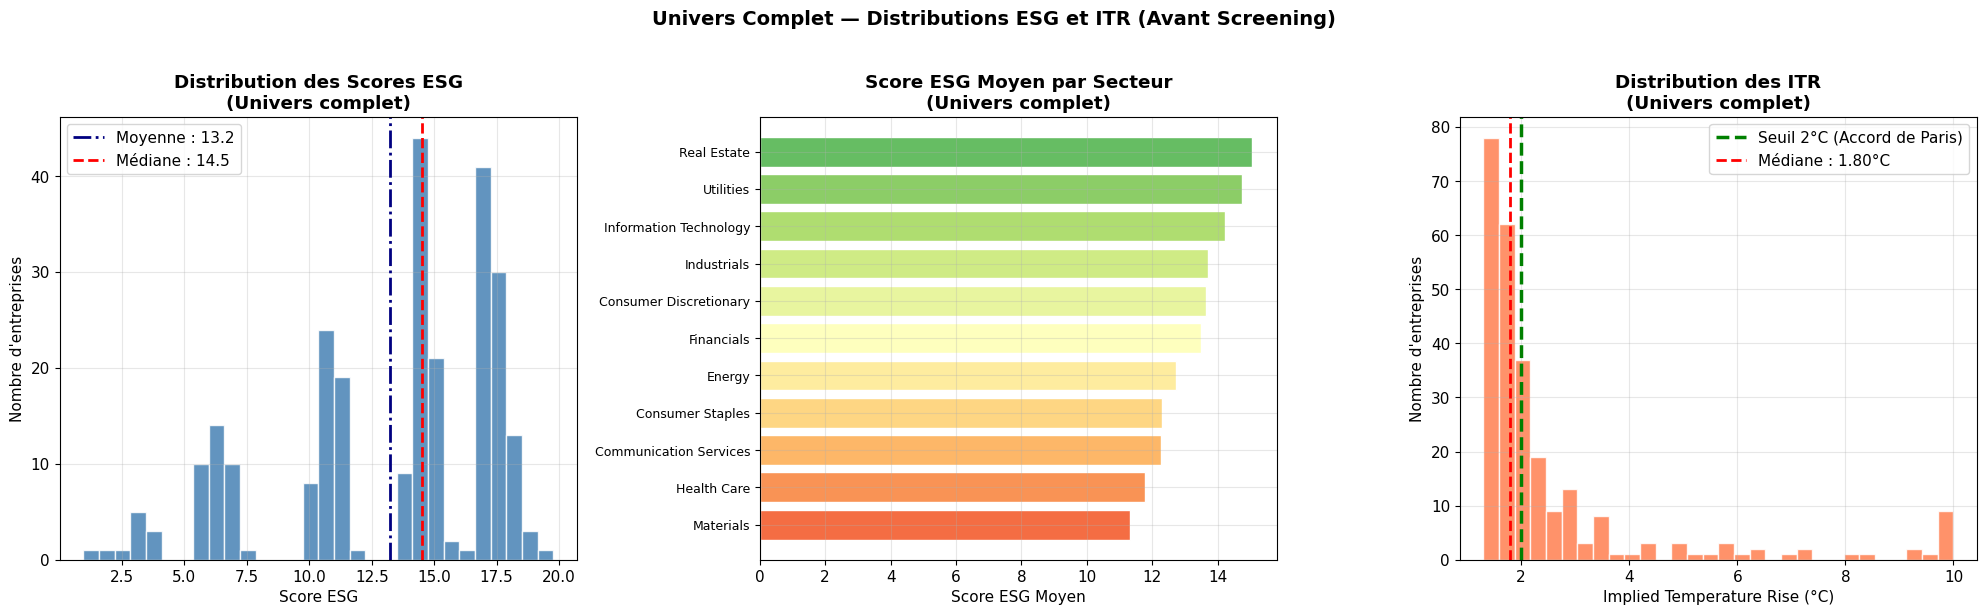

Graphique sauvegardé : P2_01_univers_avant_screening.png


In [ ]:

# SECTION 2.3 — VISUALISATION DE L'UNIVERS BRUT
#
# Trois graphiques complementaires permettent de comprendre la structure
# des donnees avant tout filtrage et motivent les choix methodologiques
# du screening presente dans les sections suivantes.


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Univers Complet — Distributions ESG et ITR (Avant Screening)",
 fontsize=14, fontweight='bold', y=1.02)

# Graphique 1 : Distribution globale des scores ESG
# La superposition de la moyenne et de la mediane revele l'asymetrie de la distribution
# et motive le recours a un screening par quantile plutot que par seuil fixe.


ax1 = axes[0]
ax1.hist(esg_latest.dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(esg_latest.mean(), color='navy', linestyle='-.', linewidth=2,
 label=f'Moyenne : {esg_latest.mean():.1f}')
ax1.axvline(esg_latest.median(), color='red', linestyle='--', linewidth=2,
 label=f'Médiane : {esg_latest.median():.1f}')
ax1.set_title("Distribution des Scores ESG\n(Univers complet)", fontweight='bold')
ax1.set_xlabel("Score ESG")
ax1.set_ylabel("Nombre d'entreprises")
ax1.legend()



# Graphique 2 : Score ESG moyen par secteur
# Ce graphique est la justification directe du screening sectoriel :
# l'amplitude des ecarts intersectoriels rend un filtrage global biaise.

ax2 = axes[1]
sector_esg_avant = esg_df_complet.groupby('SECTOR')['ESG_SCORE'].mean().sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sector_esg_avant)))
ax2.barh(range(len(sector_esg_avant)), sector_esg_avant.values, color=colors, edgecolor='white')
ax2.set_yticks(range(len(sector_esg_avant)))
ax2.set_yticklabels([s[:25] for s in sector_esg_avant.index], fontsize=9)
ax2.set_title("Score ESG Moyen par Secteur\n(Univers complet)", fontweight='bold')
ax2.set_xlabel("Score ESG Moyen")

# Graphique 3 : Distribution des ITR avec le seuil reglementaire 2 degres C
# Permet de quantifier a priori l'impact du second filtre sur la taille de l'univers.


ax3 = axes[2]
ax3.hist(itr_latest.dropna(), bins=30, color='coral', edgecolor='white', alpha=0.85)
ax3.axvline(2.0, color='green', linestyle='--', linewidth=2.5,
 label='Seuil 2°C (Accord de Paris)')
ax3.axvline(itr_latest.median(), color='red', linestyle='--', linewidth=2,
 label=f'Médiane : {itr_latest.median():.2f}°C')
ax3.set_title("Distribution des ITR\n(Univers complet)", fontweight='bold')
ax3.set_xlabel("Implied Temperature Rise (°C)")
ax3.set_ylabel("Nombre d'entreprises")
ax3.legend()


plt.tight_layout()
plt.savefig('P2_01_univers_avant_screening.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : P2_01_univers_avant_screening.png")

## Section 3.1 — Filtre Reglementaire 1 : Exclusion des 30% Inferieurs par Secteur

Le premier filtre obligatoire est un **screening negatif sectoriel**. Il consiste a exclure, pour chaque secteur d'activite, les 30% d'entreprises presentant les scores ESG les plus faibles.

**Pourquoi un screening sectoriel et non global ?**

Un screening global appliquerait un seuil unique a l'ensemble de l'univers, sans tenir compte des differences structurelles de niveau ESG entre secteurs. Cette approche penaliserait systematiquement les secteurs dont les activites impliquent par nature des impacts environnementaux ou sociaux plus importants — energie, industrie lourde, materiaux — meme lorsque leurs entreprises sont les meilleures de leur categorie en termes de pratiques ESG. Or, la diversification sectorielle est un principe fondamental de la gestion de portefeuille : un portefeuille concentre sur les seuls secteurs "ESG-friendly" supporte des risques sectoriels specifiques non diversifiables.

Le screening sectoriel resout ce dilemme en evaluant chaque entreprise relativement a ses pairs. Un "leader ESG" est une entreprise dont les pratiques extra-financieres sont meilleures que 70% des entreprises de son secteur, quel que soit le niveau absolu de ce secteur. Cette logique est coherente avec la theorie du "best-in-class" utilisee par les grands fonds ISR institutionnels.

**Calcul du seuil :**

Pour chaque secteur, le seuil d'exclusion est le 30e percentile (quantile 0.30) de la distribution des scores ESG. Ce seuil est calcule uniquement sur les entreprises disposant d'un score valide. Les entreprises dont le score est strictement superieur a ce seuil sont retenues ; les autres sont exclues. En cas de score manquant, l'entreprise est exclue par defaut (principe de precaution).

In [ ]:

# SECTION 3.1 — FILTRE 1 : EXCLUSION DES 30% INFERIEURS PAR SECTEUR
#
# Principe : screening negatif best-in-class sectoriel.
# Pour chaque secteur, on calcule le 30e percentile des scores ESG et on
# exclut les entreprises situees en dessous de ce seuil.
#
# Justification du choix sectoriel (vs global) :
# Les scores ESG ont des niveaux structurellement differents selon les secteurs.
# Un filtrage global exclurait certains secteurs entiers (energie, materiaux)
# independamment de la qualite relative de leurs entreprises, ce qui creerait
# un biais de composition et reduirait la diversification du portefeuille.


# Construction du DataFrame de reference avec scores ESG a la date de construction

esg_series = esg_raw.loc[last_date_esg].rename('ESG_SCORE')
esg_meta = metadata[['ID', 'NAME', 'SECTOR', 'COUNTRY']].copy()
esg_meta = esg_meta.set_index('ID').join(esg_series, how='left')

print(f"Univers initial : {len(esg_meta)} entreprises")
print(f"Avec score ESG disponible : {esg_meta['ESG_SCORE'].notna().sum()} entreprises\n")

#  1.2 Calculer le seuil du 30e percentile par secteur 

seuils_sectoriels = (
 esg_meta.groupby('SECTOR')['ESG_SCORE']
 .quantile(0.30)
 .rename('SEUIL_30pct')
)

print("Seuils d'exclusion (30e percentile) par secteur :")
print("-" * 55)
for sector, seuil in seuils_sectoriels.sort_values().items():
 n_entreprises = (esg_meta['SECTOR'] == sector).sum()
 print(f" {sector:<35} → {seuil:6.2f} (n={n_entreprises})")

# 1.3 Appliquer l'exclusion 
esg_meta = esg_meta.join(seuils_sectoriels, on='SECTOR')
masque_inclusion = (
 esg_meta['ESG_SCORE'].notna() &
 (esg_meta['ESG_SCORE'] > esg_meta['SEUIL_30pct'])
)
univers_apres_esg = esg_meta[masque_inclusion].copy()



n_exclu = len(esg_meta) - len(univers_apres_esg)
print(f"\n{'='*55}")
print(f"Entreprises exclues (30% inférieurs ESG) : {n_exclu}")
print(f"Entreprises RETENUES après filtre ESG : {len(univers_apres_esg)}")
print(f"Taux de réduction : {n_exclu/len(esg_meta)*100:.1f}%")


# Rapport detaille par secteur pour verifier la coherence du filtrage
print("\nRécapitulatif par secteur après exclusion ESG :")
print("-" * 55)
for sector in sorted(esg_meta['SECTOR'].dropna().unique()):
 n_avant = (esg_meta['SECTOR'] == sector).sum()
 n_apres = (univers_apres_esg['SECTOR'] == sector).sum()
 print(f" {sector:<35} : {n_avant} → {n_apres} (exclu: {n_avant - n_apres})")


n_sans_secteur = esg_meta['SECTOR'].isna().sum()
if n_sans_secteur > 0:
 print(f"\n {n_sans_secteur} entreprise(s) sans secteur renseigné -> exclues par défaut")

Univers initial : 269 entreprises
Avec score ESG disponible : 263 entreprises

Seuils d'exclusion (30e percentile) par secteur :
-------------------------------------------------------
 Materials                           →   6.85 (n=23)
 Health Care                         →   9.94 (n=23)
 Consumer Staples                    →  10.51 (n=19)
 Communication Services              →  10.90 (n=17)
 Industrials                         →  11.02 (n=48)
 Financials                          →  11.40 (n=55)
 Energy                              →  12.08 (n=9)
 Consumer Discretionary              →  12.24 (n=30)
 Information Technology              →  14.12 (n=13)
 Real Estate                         →  14.60 (n=9)
 Utilities                           →  14.65 (n=22)

Entreprises exclues (30% inférieurs ESG) : 89
Entreprises RETENUES après filtre ESG : 180
Taux de réduction : 33.1%

Récapitulatif par secteur après exclusion ESG :
-------------------------------------------------------
 Communicati

## Section 3.2 — Filtre Reglementaire 2 : Alignement Trajectoire 2 Degres C (ITR)

Le second filtre obligatoire est un **filtre de compatibilite climatique**. Il retient uniquement les entreprises dont l'ITR (Implied Temperature Rise) est inferieur ou egal a 2 degres Celsius.

**Qu'est-ce que l'ITR ?**

L'ITR est une metrique developpee dans le cadre des travaux sur l'alignement des portefeuilles avec les objectifs climatiques de l'Accord de Paris. Elle repond a la question suivante : si toutes les entreprises du monde avaient la meme trajectoire de reduction des emissions que l'entreprise analysee, de combien de degres la temperature globale augmenterait-elle d'ici 2100 ? Un ITR de 1.8 degres C signifie que cette entreprise est alignee avec l'objectif de 2 degres C. Un ITR de 3.5 degres C signifie que l'entreprise suit une trajectoire incompatible avec les objectifs climatiques.

**Pourquoi ce seuil a 2 degres C ?**

L'Accord de Paris (2015) fixe comme objectif de maintenir le rechauffement climatique "bien en dessous de 2 degres C par rapport aux niveaux preindustriels". Ce seuil de 2 degres C est donc la reference reglementaire internationale. En n'investissant que dans des entreprises dont l'ITR est inferieur ou egal a ce seuil, le portefeuille est par construction aligne avec les engagements climatiques internationaux.

**Traitement des donnees manquantes :**

Les entreprises pour lesquelles aucune donnee ITR n'est disponible sont exclues par principe de precaution. L'absence de donnee ITR ne permet pas de garantir la conformite climatique du titre, et une inclusion sans information serait contraire a la logique de responsabilite qui fonde la strategie.

In [ ]:

# SECTION 3.2 — FILTRE 2 : ALIGNEMENT TRAJECTOIRE 2 DEGRES C (ITR)
#
# L'ITR (Implied Temperature Rise) mesure la compatibilite de la trajectoire
# d'emissions d'une entreprise avec l'Accord de Paris (2015).
# Seuil retenu : ITR <= 2.0 degres C — reference reglementaire internationale.
#
# Les titres sans donnee ITR sont exclus par principe de precaution :
# l'absence d'information ne permet pas de garantir la conformite climatique.


itr_series = itr_raw.loc[last_date_itr].rename('ITR')
univers_apres_esg = univers_apres_esg.join(itr_series, how='left')

print(f"Date de référence ITR : {last_date_itr.date()}")
print(f"\nDistribution des ITR dans l'univers post-ESG :")
print(f" Disponibles : {univers_apres_esg['ITR'].notna().sum()} entreprises")
print(f" ITR moyen : {univers_apres_esg['ITR'].mean():.2f}°C")
print(f" ITR médian : {univers_apres_esg['ITR'].median():.2f}°C")
print(f" ITR ≤ 2°C : {(univers_apres_esg['ITR'] <= 2.0).sum()} entreprises")
print(f" ITR > 2°C : {(univers_apres_esg['ITR'] > 2.0).sum()} entreprises")
print(f" ITR manquant : {univers_apres_esg['ITR'].isna().sum()} entreprises")


masque_2C = univers_apres_esg['ITR'].notna() & (univers_apres_esg['ITR'] <= 2.0)
univers_final = univers_apres_esg[masque_2C].copy()

print(f"\n{'='*55}")

print(f"Après filtre alignement 2°C :")
print(f" Entreprises retenues : {len(univers_final)}")
print(f" Entreprises exclues : {len(univers_apres_esg) - len(univers_final)}")

print(f"\nRécapitulatif du pipeline de filtrage :")
print(f" Univers initial : {len(metadata)} titres")
print(f" Après exclusion ESG 30% : {len(univers_apres_esg)} titres")
print(f" Après filtre ITR ≤ 2°C : {len(univers_final)} titres")
print(f" Taux de réduction total : {(1 - len(univers_final)/len(metadata))*100:.1f}%")


tickers_eligibles = univers_final.index.tolist()
print(f"\nPremiers tickers éligibles : {tickers_eligibles[:10]}")

Date de référence ITR : 2025-09-30

Distribution des ITR dans l'univers post-ESG :
 Disponibles : 177 entreprises
 ITR moyen : 2.44°C
 ITR médian : 1.80°C
 ITR ≤ 2°C : 114 entreprises
 ITR > 2°C : 63 entreprises
 ITR manquant : 3 entreprises

Après filtre alignement 2°C :
 Entreprises retenues : 114
 Entreprises exclues : 66

Récapitulatif du pipeline de filtrage :
 Univers initial : 269 titres
 Après exclusion ESG 30% : 180 titres
 Après filtre ITR ≤ 2°C : 114 titres
 Taux de réduction total : 57.6%

Premiers tickers éligibles : ['ADSG.DE', 'AENA.MC', 'AGN.AS', 'AGS.BR', 'AH.AS', 'ALO.PA', 'ALVG.DE', 'AMS.MC', 'ANA.MC', 'ANE.MC']


## Section 3.3 — Mesure de l'Impact du Screening : Comparaison Avant / Apres

Cette section est methodologiquement importante car elle etablit la **valeur ajoutee extra-financiere du screening**. Il ne suffit pas d'appliquer des filtres — il faut demontrer que ces filtres ameliorent effectivement le profil ESG et climatique de l'univers, et qu'ils le font sans detruire la diversification du portefeuille.

Le tableau de comparaison produit ici permet de repondre a quatre questions essentielles :

**1. L'amelioration ESG est-elle significative ?**
On mesure l'augmentation du score ESG moyen et median entre l'univers brut et l'univers filtre. Une amelioration notable valide que le screening est efficace et que les entreprises retenues sont effectivement de meilleure qualite ESG que la moyenne initiale.

**2. Le filtre climatique est-il contraignant ?**
La reduction de l'ITR moyen entre les deux univers montre dans quelle mesure le filtre 2 degres C exclut des entreprises a forte empreinte carbone. Un ITR moyen nettement inferieur apres filtrage confirme l'alignement climatique effectif du portefeuille.

**3. La diversification sectorielle est-elle preservee ?**
Le maintien d'un nombre comparable de secteurs representés apres le screening est un critere de qualite important. Si le screening detruisait la representation sectorielle, le portefeuille serait expose a des risques de concentration non desires, independamment de ses qualites ESG.

**4. La couverture geographique reste-t-elle adequate ?**
De meme, le nombre de pays representes dans l'univers filtre indique si la strategie conserve une diversification geographique suffisante pour limiter les risques pays et les correlations regionales.

In [ ]:

# SECTION 3.3 — COMPARAISON QUANTITATIVE AVANT / APRES SCREENING
#
# Ce tableau mesure la valeur ajoutee extra-financiere du double filtrage
# en comparant les indicateurs cles de l'univers avant et apres les deux filtres.
# Il permet de verifier que le screening ameliore le profil ESG/climatique
# tout en preservant une diversification sectorielle et geographique suffisante.


# DataFrame synthetique de l'univers filtre pour les comparaisons
esg_df_apres = pd.DataFrame({
 'ESG_SCORE': univers_final['ESG_SCORE'],
 'ITR' : univers_final['ITR'],
 'SECTOR' : univers_final['SECTOR'],
 'COUNTRY' : univers_final['COUNTRY']
})

print("=" * 65)

print("COMPARAISON AVANT / APRÈS DOUBLE SCREENING")
print("=" * 65)
print(f"\n {'Indicateur':<35} {'Avant':>10} {'Après':>10} {'Variation':>10}")

print(f" {'-'*65}")


n_avant = len(esg_meta)
n_apres = len(univers_final)
esg_moy_avant = esg_meta['ESG_SCORE'].mean()
esg_moy_apres = univers_final['ESG_SCORE'].mean()
esg_med_avant = esg_meta['ESG_SCORE'].median()
esg_med_apres = univers_final['ESG_SCORE'].median()
itr_moy_avant = esg_df_complet['ITR'].mean()
itr_moy_apres = univers_final['ITR'].mean()
sec_avant = esg_meta['SECTOR'].nunique()
sec_apres = univers_final['SECTOR'].nunique()
pay_avant = esg_meta['COUNTRY'].nunique()
pay_apres = univers_final['COUNTRY'].nunique()

print(f" {'Nb d\'entreprises':<35} {n_avant:>10} {n_apres:>10} {n_apres-n_avant:>+10}")
print(f" {'Score ESG moyen':<35} {esg_moy_avant:>10.2f} {esg_moy_apres:>10.2f} {esg_moy_apres-esg_moy_avant:>+10.2f}")
print(f" {'Score ESG médian':<35} {esg_med_avant:>10.2f} {esg_med_apres:>10.2f} {esg_med_apres-esg_med_avant:>+10.2f}")
print(f" {'ITR moyen (°C)':<35} {itr_moy_avant:>10.2f} {itr_moy_apres:>10.2f} {itr_moy_apres-itr_moy_avant:>+10.2f}")
print(f" {'Nombre de secteurs':<35} {sec_avant:>10} {sec_apres:>10} {sec_apres-sec_avant:>+10}")
print(f" {'Nombre de pays':<35} {pay_avant:>10} {pay_apres:>10} {pay_apres-pay_avant:>+10}")



print(f"\n--- Score ESG moyen par secteur : Avant vs Après ---")
print(f" {'Secteur':<35} {'ESG avant':>10} {'ESG après':>10} {'N avant':>8} {'N après':>8}")
print(f" {'-'*73}")


sector_stats_apres = esg_df_apres.groupby('SECTOR').agg(
 N_apres = ('ESG_SCORE', 'count'),
 ESG_apres = ('ESG_SCORE', 'mean')
)

for sector in sorted(esg_meta['SECTOR'].dropna().unique()):
 esg_av = sector_stats_avant.loc[sector, 'ESG_moy'] if sector in sector_stats_avant.index else np.nan
 n_av = int(sector_stats_avant.loc[sector, 'N']) if sector in sector_stats_avant.index else 0
 esg_ap = sector_stats_apres.loc[sector, 'ESG_apres'] if sector in sector_stats_apres.index else np.nan
 n_ap = int(sector_stats_apres.loc[sector, 'N_apres']) if sector in sector_stats_apres.index else 0
 esg_av_s = f"{esg_av:.2f}" if not np.isnan(esg_av) else "N/A"
 esg_ap_s = f"{esg_ap:.2f}" if not np.isnan(esg_ap) else "0"
 print(f" {sector:<35} {esg_av_s:>10} {esg_ap_s:>10} {n_av:>8} {n_ap:>8}")

COMPARAISON AVANT / APRÈS DOUBLE SCREENING

 Indicateur                               Avant      Après  Variation
 -----------------------------------------------------------------
 Nb d'entreprises                           269        114       -155
 Score ESG moyen                          13.22      15.82      +2.60
 Score ESG médian                         14.50      16.85      +2.35
 ITR moyen (°C)                            2.55       1.60      -0.95
 Nombre de secteurs                          11         11         +0
 Nombre de pays                              11         10         -1

--- Score ESG moyen par secteur : Avant vs Après ---
 Secteur                              ESG avant  ESG après  N avant  N après
 -------------------------------------------------------------------------
 Communication Services                   12.26      14.93       16        9
 Consumer Discretionary                   13.64      16.44       29       14
 Consumer Staples                      

## Section 3.4 — Visualisation de l'Impact du Screening

Les quatre graphiques suivants completent l'analyse quantitative par une representation visuelle de l'impact du double filtrage. Ensemble, ils constituent la demonstration visuelle que le screening est a la fois efficace (il ameliore le profil ESG) et equilibre (il preserve la diversification).

**Graphique 1 — Distribution ESG avant vs apres :**
La superposition des deux histogrammes montre le deplacement de la distribution vers les scores plus eleves apres filtrage. Le glissement vers la droite de la distribution bleu (apres) par rapport au gris (avant) quantifie visuellement le gain ESG median et moyen produit par le screening.

**Graphique 2 — Nombre de titres par secteur avant vs apres :**
Ce graphique a barres groupees permet de verifier que le screening ne provoque pas l'elimination complete d'un secteur. Une reduction proportionnelle et homogene entre secteurs valide l'approche best-in-class : chaque secteur conserve ses meilleurs representants ESG dans l'univers investissable.

**Graphique 3 — Score ESG moyen par secteur avant vs apres :**
Pour chaque secteur, la comparaison des scores moyens avant et apres filtrage confirme que le screening a bien releve le niveau de qualite ESG intra-sectorielle. Un score moyen plus eleve apres filtrage dans chaque secteur valide que les entreprises retenues sont bien les leaders ESG de leur categorie.

**Graphique 4 — Distribution ITR avant vs apres :**
La concentration de la distribution ITR a gauche du seuil 2 degres C apres filtrage confirme l'alignement climatique de l'univers resultant. Ce graphique est la preuve directe de la conformite du portefeuille avec l'Accord de Paris.

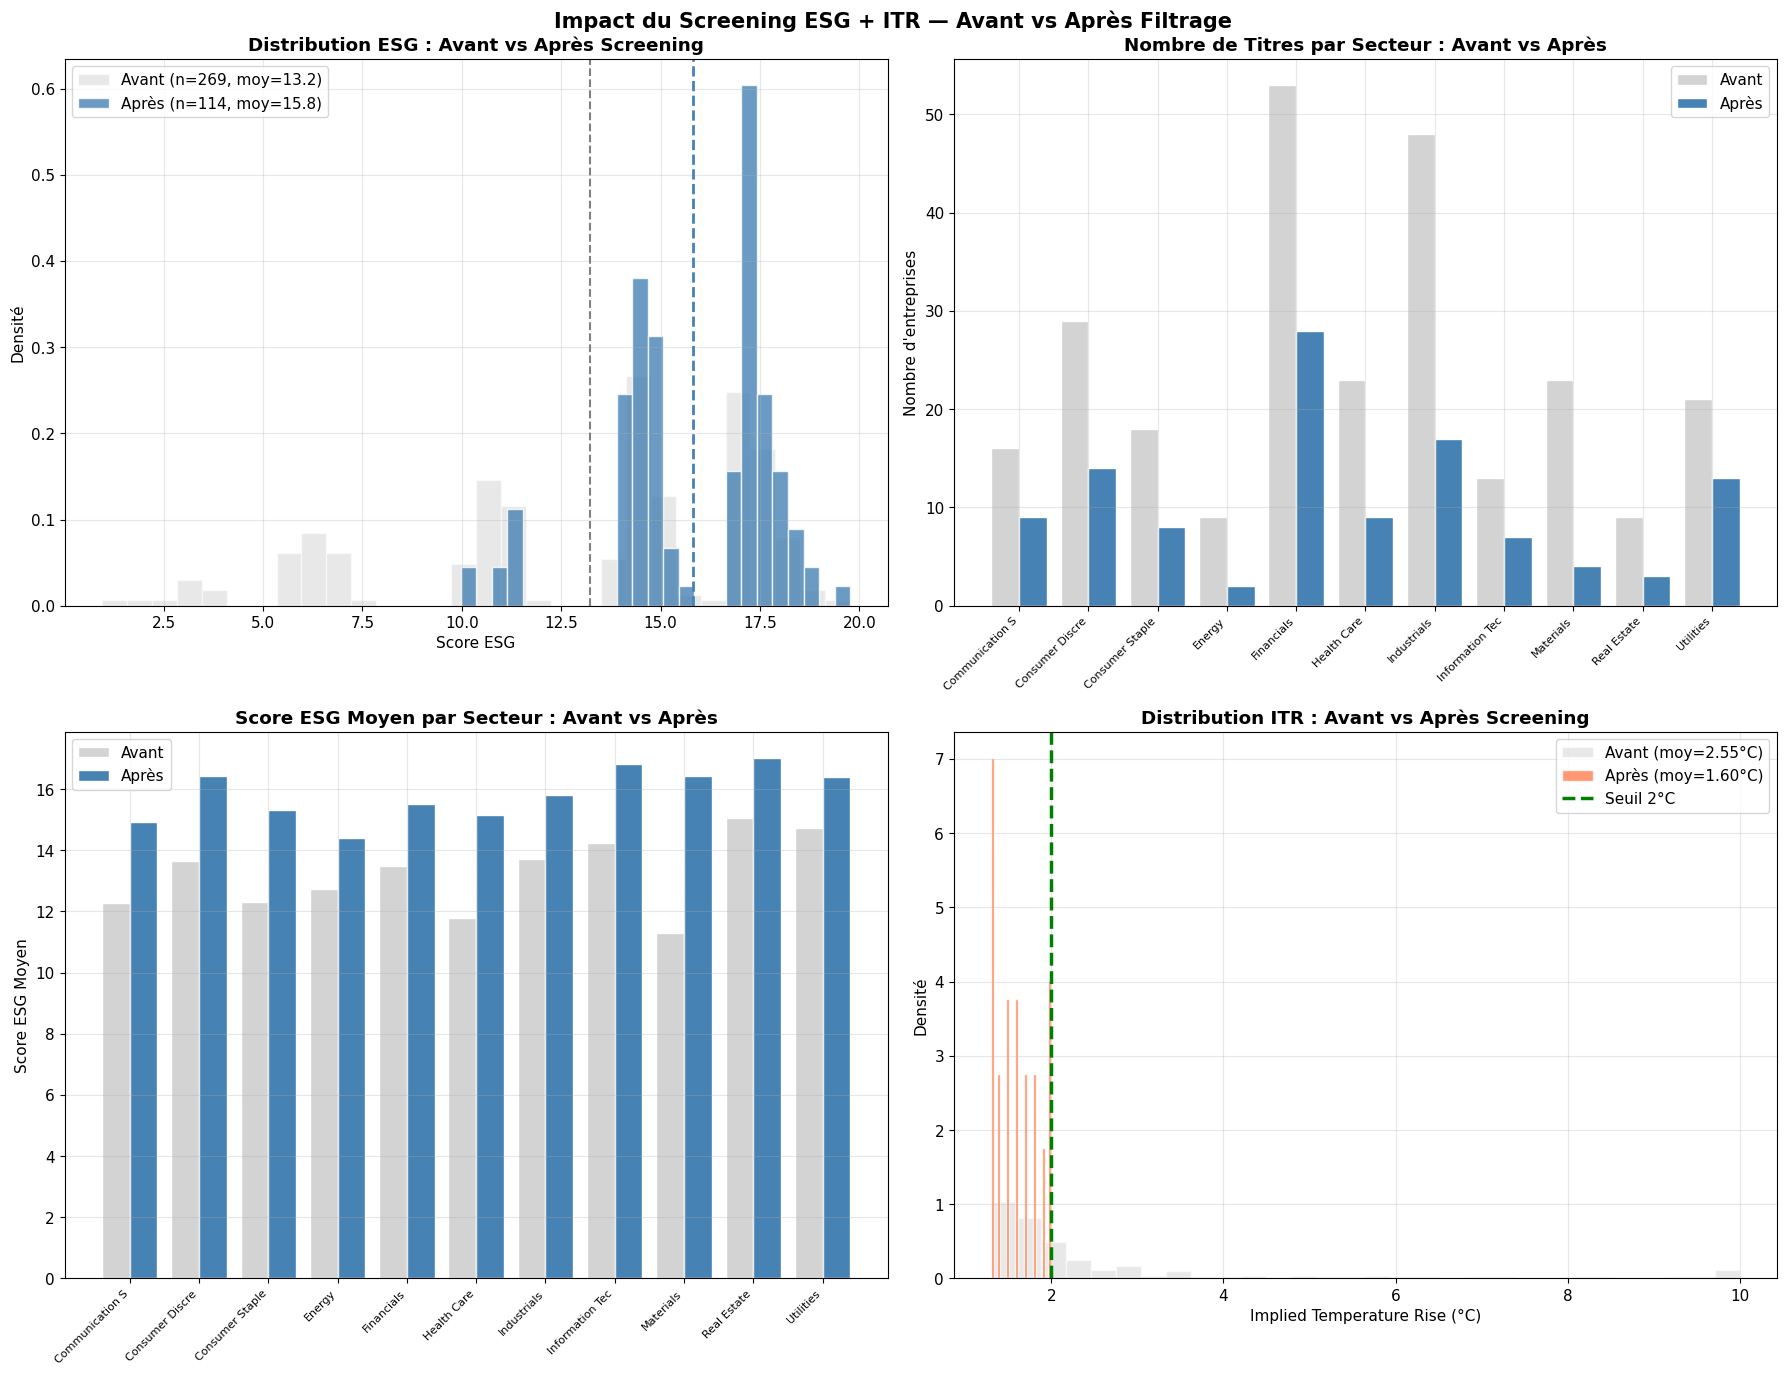

Graphique sauvegardé : P2_02_impact_screening.png


In [ ]:

# SECTION 3.4 — VISUALISATION DE L'IMPACT DU DOUBLE SCREENING
#
# Quatre graphiques complementaires demontrent visuellement que le screening :
# (1) ameliore le profil ESG de l'univers (distribution vers les scores eleves)
# (2) preserve la representativite sectorielle (pas d'elimination de secteur)
# (3) releve le niveau ESG intra-sectoriel (leaders retenus dans chaque secteur)
# (4) aligne effectivement l'univers sur la trajectoire 2 degres C




fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Impact du Screening ESG + ITR — Avant vs Après Filtrage",
 fontsize=15, fontweight='bold')

# Graphique 1 : Deplacement de la distribution ESG vers les scores superieurs
# La densite (density=True) permet une comparaison equitable malgre des effectifs differents


ax1 = axes[0, 0]
ax1.hist(esg_meta['ESG_SCORE'].dropna(), bins=30, alpha=0.5, color='lightgray',
 edgecolor='white', label=f'Avant (n={len(esg_meta)}, moy={esg_moy_avant:.1f})', density=True)
ax1.hist(univers_final['ESG_SCORE'].dropna(), bins=25, alpha=0.8, color='steelblue',
 edgecolor='white', label=f'Après (n={len(univers_final)}, moy={esg_moy_apres:.1f})', density=True)
ax1.axvline(esg_moy_avant, color='gray', linestyle='--', linewidth=1.5)
ax1.axvline(esg_moy_apres, color='steelblue', linestyle='--', linewidth=2)
ax1.set_title("Distribution ESG : Avant vs Après Screening", fontweight='bold')
ax1.set_xlabel("Score ESG")
ax1.set_ylabel("Densité")
ax1.legend()

# Graphique 2 : Reduction proportionnelle par secteur
# Valide que le screening ne concentre pas le portefeuille sur certains secteurs


ax2 = axes[0, 1]
secteurs_tous = sorted(esg_meta['SECTOR'].dropna().unique())
n_avant_list = [int(sector_stats_avant.loc[s, 'N']) if s in sector_stats_avant.index else 0 for s in secteurs_tous]
n_apres_list = [int(sector_stats_apres.loc[s, 'N_apres']) if s in sector_stats_apres.index else 0 for s in secteurs_tous]
x = np.arange(len(secteurs_tous))
bars1 = ax2.bar(x - 0.2, n_avant_list, 0.4, label='Avant', color='lightgray', edgecolor='white')
bars2 = ax2.bar(x + 0.2, n_apres_list, 0.4, label='Après', color='steelblue', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels([s[:15] for s in secteurs_tous], rotation=45, ha='right', fontsize=8)
ax2.set_title("Nombre de Titres par Secteur : Avant vs Après", fontweight='bold')
ax2.set_ylabel("Nombre d'entreprises")
ax2.legend()

# Graphique 3 : Elevation du score ESG moyen dans chaque secteur
# Confirme que les entreprises retenues sont bien les leaders ESG intra-sectoriels


ax3 = axes[1, 0]
esg_av_list = [sector_stats_avant.loc[s, 'ESG_moy'] if s in sector_stats_avant.index else 0 for s in secteurs_tous]
esg_ap_list = [sector_stats_apres.loc[s, 'ESG_apres'] if s in sector_stats_apres.index else 0 for s in secteurs_tous]
bars3 = ax3.bar(x - 0.2, esg_av_list, 0.4, label='Avant', color='lightgray', edgecolor='white')
bars4 = ax3.bar(x + 0.2, esg_ap_list, 0.4, label='Après', color='steelblue', edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels([s[:15] for s in secteurs_tous], rotation=45, ha='right', fontsize=8)
ax3.set_title("Score ESG Moyen par Secteur : Avant vs Après", fontweight='bold')
ax3.set_ylabel("Score ESG Moyen")
ax3.legend()

# Graphique 4 : Concentration de l'univers filtre sous le seuil 2 degres C
# Preuve visuelle de l'alignement climatique effectif du portefeuille


ax4 = axes[1, 1]
ax4.hist(esg_df_complet['ITR'].dropna(), bins=30, alpha=0.5, color='lightgray',
 edgecolor='white', label=f'Avant (moy={itr_moy_avant:.2f}°C)', density=True)
ax4.hist(univers_final['ITR'].dropna(), bins=20, alpha=0.8, color='coral',
 edgecolor='white', label=f'Après (moy={itr_moy_apres:.2f}°C)', density=True)
ax4.axvline(2.0, color='green', linestyle='--', linewidth=2.5, label='Seuil 2°C')
ax4.set_title("Distribution ITR : Avant vs Après Screening", fontweight='bold')
ax4.set_xlabel("Implied Temperature Rise (°C)")
ax4.set_ylabel("Densité")
ax4.legend()

plt.tight_layout()
plt.savefig('P2_02_impact_screening.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : P2_02_impact_screening.png")

## Section 4 — Modele Black-Litterman Dynamique : Architecture et Pertinence

Cette section est le coeur methodologique de la strategie. Elle definit la fonction `construire_portefeuille()` qui encapsule l'integralite du pipeline quantitatif. Comprendre cette fonction, c'est comprendre la logique d'investissement dans sa totalite.

### Le modele Black-Litterman : principe et justification

Le modele de Black-Litterman resout un probleme central de la gestion quantitative : l'optimisation moyenne-variance classique de Markowitz produit des portefeuilles hypersensibles aux erreurs d'estimation des rendements attendus. Une petite perturbation des rendements esperés peut conduire a des allocations radicalement differentes, souvent concentrees sur quelques titres et peu diversifiees en pratique.

Black-Litterman propose une solution bayesienne. Le point de depart est un **prior de marche** : les rendements d'equilibre qui rendraient chaque investisseur satisfait de detenir le portefeuille de marche. Ces rendements d'equilibre, notes Pi, sont derives du CAPM :

 Pi = delta * Sigma * w_mkt

ou delta est l'aversion au risque implicite du marche, Sigma la matrice de covariance annualisee, et w_mkt les poids du portefeuille de marche. Ce prior est neutral : il ne suppose aucune surperformance d'aucun titre.

Le gestionnaire exprime ensuite ses **convictions** sous forme de views — des previsions de rendement pour certains titres ou combinaisons de titres. Ces views sont encodees dans un vecteur Q et une matrice P. La mise a jour bayesienne combine le prior Pi et les views Q pour produire les rendements posterieurs mu_BL :

 mu_BL = [(tau*Sigma)^{-1} + P'*Omega^{-1}*P]^{-1} * [(tau*Sigma)^{-1}*Pi + P'*Omega^{-1}*Q]

Le parametre tau controle le poids relatif du prior (faible tau = forte confiance dans l'equilibre de marche). La matrice Omega encode l'incertitude sur chaque view : une view precise (faible Omega) aura plus d'influence sur mu_BL qu'une view incertaine.

### Les views ESG : integration de la durabilite dans l'optimisation

Dans notre strategie, les views encodent une conviction economique precise : les entreprises ayant de meilleures pratiques ESG sont susceptibles de generer des rendements superieurs a leur equilibre de marche sur le long terme. Cette conviction repose sur plusieurs mecanismes etablis dans la litterature :

- Les entreprises bien notees ESG sont exposees a moins de risques reglementaires, de scandales de gouvernance et de litiges sociaux ou environnementaux.
- Elles ont generalement un meilleur acces aux capitaux (les flux vers les fonds ESG ont fortement augmente depuis 2015).
- La qualite de gouvernance (composante G du score ESG) est correlee positivement avec la qualite du management et les decisions d'allocation du capital.

### Views composites : score statique et momentum ESG

La la strategie initiale construisait les views uniquement a partir du score ESG courant. La la presente version introduit une **view composite** qui integre deux dimensions :

**Dimension 1 — Score ESG statique (poids 70%) :**
Le score ESG courant de l'entreprise, normalise entre 0 et 1 au sein de son secteur (normalisation Min-Max sectorielle). La normalisation sectorielle est cruciale : elle garantit que la view ESG compare l'entreprise a ses pairs, pas a l'ensemble de l'univers. Un leader ESG dans le secteur Energie recoit une view elevee meme si son score absolu est inferieur a celui d'une entreprise du secteur Technologie.

**Dimension 2 — Momentum ESG (poids 30%) :**
La variation du score ESG sur les 6 derniers mois disponibles, normalisee entre 0 et 1. Ce signal capture la **trajectoire** de l'entreprise : une entreprise qui ameliore systematiquement ses pratiques ESG est susceptible de continuer sur cette tendance (effet momentum). Inversement, une entreprise dont le score se degrade est un signal d'alerte sur la deterioration de ses pratiques.

La view composite est definie comme :

 view_composite_i = 0.70 * ESG_normalise_i + 0.30 * momentum_normalise_i

La view finale transmise a Black-Litterman est centree sur zero :

 Q_i = Pi_i + alpha_calibre * (2 * view_composite_i - 1)

Un titre avec view_composite = 1 (leader absolu avec forte progression ESG) recoit une view de Pi + alpha. Un titre avec view_composite = 0 (laggard avec forte degradation) recoit Pi - alpha. Un titre median (0.5) n'est pas revise par rapport a l'equilibre de marche.

### Alpha dynamique : calibration au regime de marche

Dans la la strategie initiale, alpha = 0.03 est un parametre fixe arbitraire. Cette fixite est problematique : l'intensite des views ESG devrait etre proportionnelle a la dispersion reelle des rendements observes. Dans un regime de forte dispersion des rendements (marche directionnel avec fortes differences entre valeurs), les views ESG ont une signification economique plus forte. Dans un regime de faible dispersion (marche homogene), les views devraient etre attenueees.

En la presente version, alpha est calcule dynamiquement a chaque rebalancement comme l'ecart-type cross-sectionnel des rendements annuels de la fenetre de train :

 alpha_t = std(rendements annuels de tous les titres sur la fenetre train)

Ce parametre est borne entre 1% et 8% pour eviter des valeurs extremes dans des regimes de marche inhabituels. Cette calibration dynamique assure que l'intensite des convictions ESG est toujours ancree dans la realite des donnees de marche observees.

In [ ]:

# SECTION 4 — PIPELINE BLACK-LITTERMAN AVEC VIEWS ESG DYNAMIQUES
#
# Cette fonction encapsule l'integralite du pipeline quantitatif de la strategie.
# Elle est concue pour etre appelee a chaque date de rebalancement dans la boucle
# walk-forward, en ne recevant que les donnees disponibles jusqu'a date_fin_train.
# Aucune information posterieure a cette date n'est utilisee (principe anti-lookahead).
#
# Le pipeline suit cinq etapes sequentielles :
#   Etape 1 : Filtrage ESG et ITR sur la fenetre de train
#   Etape 2 : Preparation des donnees de marche et calcul des rendements
#   Etape 3 : Estimation de la matrice de covariance par la methode Ledoit-Wolf
#   Etape 4 : Construction des rendements posterieurs Black-Litterman
#   Etape 5 : Optimisation du ratio de Sharpe sous contraintes
#
# PARAMETRES DE LA VIEW COMPOSITE :
#   W_STATIQUE = 0.70 : poids du score ESG courant (ancre fondamentale de la view)
#   W_MOMENTUM = 0.30 : poids du momentum ESG sur 6 mois (dimension temporelle)


W_STATIQUE = 0.70
W_MOMENTUM = 0.30


def construire_portefeuille(date_fin_train, date_debut_train=None, annees_train=3, verbose=False):
    """
    Reconstruit le portefeuille BL-ESG a partir des donnees disponibles
    jusqu'a date_fin_train (incluse).

    Parametres :
        date_fin_train   : derniere date de la fenetre de train
        date_debut_train : premiere date (si None, fixee a date_fin_train - annees_train)
        annees_train     : duree de la fenetre d'estimation en annees
        verbose          : afficher les details de construction ou non

    Retourne :
        poids_final, mu_BL, cov_bl, tickers_bl, univers_t, metriques, alpha_calibre
    """

    if date_debut_train is None:
        date_debut_train = date_fin_train - pd.DateOffset(years=annees_train)



    # -------------------------------------------------------------------------
    # ETAPE 1 : FILTRAGE ESG ET ITR SUR LA FENETRE DE TRAIN
    #
    # On applique les memes filtres reglementaires que dans les sections precedentes,
    # mais uniquement sur les donnees disponibles jusqu'a date_fin_train.
    # C'est la garantie fondamentale contre le biais de lookahead :
    # les seuils ESG par secteur et les valeurs ITR sont calcules a cette date
    # et ne tiennent compte d'aucune information future.
    # -------------------------------------------------------------------------



    esg_t = esg_raw.loc[:date_fin_train].iloc[-1].rename('ESG_SCORE')
    itr_t = itr_raw.loc[:date_fin_train].iloc[-1].rename('ITR')

    esg_meta_t = metadata[['ID', 'NAME', 'SECTOR', 'COUNTRY']].copy().set_index('ID')
    esg_meta_t = esg_meta_t.join(esg_t, how='left')

    # Filtre ESG : exclusion des 30% inferieurs par secteur
    seuils_t   = esg_meta_t.groupby('SECTOR')['ESG_SCORE'].quantile(0.30).rename('SEUIL_30')
    esg_meta_t = esg_meta_t.join(seuils_t, on='SECTOR')
    masque_esg_t = (
        esg_meta_t['ESG_SCORE'].notna() &
        (esg_meta_t['ESG_SCORE'] > esg_meta_t['SEUIL_30'])
    )
    univ_t = esg_meta_t[masque_esg_t].copy()

    # Filtre ITR : alignement trajectoire 2 degres C
    univ_t       = univ_t.join(itr_t, how='left')
    masque_itr_t = univ_t['ITR'].notna() & (univ_t['ITR'] <= 2.0)
    univ_t       = univ_t[masque_itr_t].copy()

    tickers_elig_t = univ_t.index.tolist()
    if len(tickers_elig_t) < 5:
        return None, None, None, None, None, None, None
    

    # -------------------------------------------------------------------------
    # ETAPE 2 : PREPARATION DES DONNEES DE MARCHE
    #
    # On extrait les prix de la fenetre [date_debut_train, date_fin_train].
    # Seuil de qualite : on exclut les titres avec plus de 20% de NaN sur la
    # fenetre d'estimation, car une covariance calculee sur des donnees tres
    # lacunaires serait numeriquement instable.
    # Les NaN residuels sont combles par forward-fill puis backward-fill.
    # -------------------------------------------------------------------------



    tickers_dispo_t = [t for t in tickers_elig_t if t in price_raw.columns]
    prices_t        = price_raw.loc[date_debut_train:date_fin_train, tickers_dispo_t].copy()

    validite_t    = prices_t.notna().mean()
    tickers_val_t = validite_t[validite_t >= 0.80].index.tolist()
    prices_t      = prices_t[tickers_val_t].ffill().bfill()

    if len(tickers_val_t) < 5 or len(prices_t) < 60:
        return None, None, None, None, None, None, None

    log_ret_t           = np.log(prices_t / prices_t.shift(1)).dropna()
    rendement_annuel_t  = log_ret_t.mean() * JOURS_TRADING
    volatilite_annuel_t = log_ret_t.std()  * np.sqrt(JOURS_TRADING)



    # -------------------------------------------------------------------------
    # ETAPE 3 : ESTIMATION DE LA MATRICE DE COVARIANCE (LEDOIT-WOLF)
    #
    # L'estimateur de Ledoit-Wolf applique un shrinkage : il contracte la matrice
    # de covariance empirique vers une cible structuree (matrice diagonale scalee).
    # Cette regularisation est cruciale lorsque le nombre de titres N est grand
    # par rapport au nombre d'observations T, car la matrice empirique contient
    # alors beaucoup de bruit d'estimation. Le coefficient de shrinkage optimal
    # est calcule analytiquement par Ledoit et Wolf (2004), sans validation croisee.
    # -------------------------------------------------------------------------



    lw_t  = LedoitWolf()
    lw_t.fit(log_ret_t)
    cov_t = pd.DataFrame(
        lw_t.covariance_ * JOURS_TRADING,
        index=tickers_val_t,
        columns=tickers_val_t
    )

    # -------------------------------------------------------------------------
    # ETAPE 4 : MODELE BLACK-LITTERMAN AVEC VIEWS ESG DYNAMIQUES
    #
    # Cette etape est le coeur de la strategie. Elle transforme les scores ESG
    # en rendements attendus ajustes via la mise a jour bayesienne de Black-Litterman.
    # Deux innovations rendent le modele dynamique :
    #   (1) L'alpha est calibre sur la dispersion observee des rendements dans la
    #       fenetre de train, rendant l'intensite des views adaptative au regime.
    #   (2) Les views integrent un signal de momentum ESG sur 6 mois, captant la
    #       dimension temporelle de l'amelioration extra-financiere des entreprises.
    # -------------------------------------------------------------------------



    esg_scores_t = esg_t[tickers_val_t].dropna()
    tickers_bl_t = [t for t in tickers_val_t if t in esg_scores_t.index]

    if len(tickers_bl_t) < 5:
        return None, None, None, None, None, None, None

    esg_scores_t = esg_scores_t[tickers_bl_t]
    cov_bl_t     = cov_t.loc[tickers_bl_t, tickers_bl_t]
    log_ret_bl_t = log_ret_t[tickers_bl_t]
    N_t          = len(tickers_bl_t)

    # Prior de marche : poids Risk Parity (inversement proportionnels a la volatilite)
    # En l'absence de capitalisation boursiere, Risk Parity constitue un prior robuste
    # et non directionnel. Il ne suppose aucune surperformance a priori d'aucun titre.
    vols_t_bl   = log_ret_bl_t.std() * np.sqrt(JOURS_TRADING)
    w_mkt_t     = (1.0 / vols_t_bl) / (1.0 / vols_t_bl).sum()
    Sigma_t     = cov_bl_t.values
    w_mkt_arr_t = w_mkt_t[tickers_bl_t].values
    tau_t       = 1.0 / len(log_ret_bl_t)
    Pi_t        = DELTA * Sigma_t @ w_mkt_arr_t

    # Alpha dynamique : intensite des views calibree sur la dispersion observee
    # L'ecart-type cross-sectionnel des rendements annuels mesure la largeur du
    # spectre des opportunites dans la fenetre courante. Lorsque la dispersion
    # entre titres est forte, les differences ESG ont une valeur economique plus
    # elevee et les views sont amplifiees en consequence. Lorsque la dispersion
    # est faible (marche homogene), les views sont naturellement attenueees.
    # Borne entre 1% et 8% pour eviter des valeurs extremes dans des regimes inhabituels.


    alpha_calibre = float(np.clip(rendement_annuel_t[tickers_bl_t].std(), 0.01, 0.08))

    # Momentum ESG : variation du score ESG sur les 6 derniers mois disponibles
    # Ce signal capture la trajectoire temporelle de l'entreprise en matiere ESG.
    # Un titre dont le score s'ameliore de facon constante est susceptible d'etre
    # revalorise par les investisseurs responsables dans les mois suivants (effet momentum).
    # L'historique mensuel est utilise pour lisser le bruit des donnees brutes.


    esg_hist_t     = esg_raw.loc[:date_fin_train, tickers_bl_t].resample('ME').last()
    momentum_esg_t = pd.Series(0.0, index=tickers_bl_t)

    for t in tickers_bl_t:
        hist = esg_hist_t[t].dropna()
        if len(hist) >= 7:
            # Variation sur 6 mois (7 snapshots mensuels consecutifs)
            momentum_esg_t[t] = float(hist.iloc[-1] - hist.iloc[-7])
        elif len(hist) >= 2:
            # Variation sur la periode disponible si moins de 6 mois d'historique
            momentum_esg_t[t] = float(hist.iloc[-1] - hist.iloc[0])

    # Normalisation Min-Max sectorielle du score ESG statique
    # Chaque titre est evalue relativement a ses pairs sectoriels et non en absolu.
    # Un leader ESG dans le secteur Energie recoit un score normalise de 1, meme
    # si son score absolu est inferieur a la moyenne globale de l'univers.
    # Cette logique est coherente avec le screening best-in-class de l'Etape 1.


    secteurs_bl_t = univ_t.loc[tickers_bl_t, 'SECTOR']
    esg_norm_t    = pd.Series(index=tickers_bl_t, dtype=float)

    for secteur in secteurs_bl_t.unique():
        mask_s   = secteurs_bl_t == secteur
        tkrs_s   = secteurs_bl_t[mask_s].index.tolist()
        scores_s = esg_scores_t[tkrs_s]
        if scores_s.max() == scores_s.min():
            esg_norm_t[tkrs_s] = 0.5
        else:
            esg_norm_t[tkrs_s] = (scores_s - scores_s.min()) / (scores_s.max() - scores_s.min())

    # Normalisation Min-Max globale du momentum ESG
    # Le momentum est normalise globalement (non sectoriel) car la direction de
    # l'amelioration ESG est comparable entre secteurs : une hausse de score de
    # 5 points dans l'Energie a la meme signification que dans la Technologie.

    mom_min, mom_max = momentum_esg_t.min(), momentum_esg_t.max()
    if mom_max - mom_min > 1e-6:
        momentum_norm_t = (momentum_esg_t - mom_min) / (mom_max - mom_min)
    else:
        momentum_norm_t = pd.Series(0.5, index=tickers_bl_t)

    # View composite : combinaison lineaire ponderee du score statique et du momentum
    # esg_composite est dans [0, 1] : 0 = laggard absolu, 1 = leader absolu
    # La predominance du score statique (70%) ancre les views dans la notation
    # fondamentale, tandis que le momentum (30%) capte la dimension temporelle.


    esg_composite_t = W_STATIQUE * esg_norm_t + W_MOMENTUM * momentum_norm_t

    # Construction du vecteur Q et de la matrice Omega
    #
    # Formule des views :
    #   Q_i = Pi_i + alpha * (2 * composite_i - 1)
    #   composite = 1  (leader + momentum fort)  -> Q = Pi + alpha  (surperformance)
    #   composite = 0.5 (neutre)                 -> Q = Pi           (equilibre de marche)
    #   composite = 0  (laggard + degradation)   -> Q = Pi - alpha  (sous-performance)
    #
    # Matrice d'incertitude Omega :
    #   Omega_ii = tau * Sigma_ii / confiance_i
    #   Plus la view est extreme (composite eloigne de 0.5), plus la confiance est
    #   elevee, plus Omega est petit, et plus la view pese dans la mise a jour BL.


    Q_t         = Pi_t + alpha_calibre * (2 * esg_composite_t.values - 1)
    P_t         = np.eye(N_t)
    confiance_t = 0.5 + 0.5 * np.abs(2 * esg_composite_t.values - 1)
    Omega_t     = np.diag(tau_t * np.diag(Sigma_t) / confiance_t)

    # Mise a jour bayesienne de Black-Litterman
    # mu_BL = [(tau*Sigma)^{-1} + P'*Omega^{-1}*P]^{-1} * [(tau*Sigma)^{-1}*Pi + P'*Omega^{-1}*Q]

    tau_Sigma_inv_t = np.linalg.inv(tau_t * Sigma_t)
    Omega_inv_t     = np.linalg.inv(Omega_t)
    precision_t     = tau_Sigma_inv_t + P_t.T @ Omega_inv_t @ P_t
    posterior_num_t = tau_Sigma_inv_t @ Pi_t + P_t.T @ Omega_inv_t @ Q_t
    mu_BL_t         = np.linalg.inv(precision_t) @ posterior_num_t
    mu_BL_t         = pd.Series(mu_BL_t, index=tickers_bl_t)

    # -------------------------------------------------------------------------
    # ETAPE 5 : OPTIMISATION DU PORTEFEUILLE (MAXIMISATION DU RATIO DE SHARPE)
    #
    # On maximise le ratio de Sharpe en utilisant les rendements BL comme
    # rendements attendus et la matrice de covariance Ledoit-Wolf.
    #
    # Contraintes :
    #   - Somme des poids = 1 (portefeuille fully invested)
    #   - Poids individuels dans [0%, 10%] (long-only, diversification individuelle)
    #
    # L'optimisation du Sharpe est non-convexe. On utilise SLSQP avec 50 points
    # de depart aleatoires (multi-start) pour reduire le risque de convergence
    # vers un optimum local. Le meilleur ratio de Sharpe obtenu est retenu.
    # -------------------------------------------------------------------------


    
    mu_arr_t    = mu_BL_t[tickers_bl_t].values
    Sigma_arr_t = cov_bl_t.values

    def neg_sharpe_t(w):
        rp = w @ mu_arr_t
        vp = np.sqrt(w @ Sigma_arr_t @ w)
        return -(rp - TAUX_SANS_RISQUE) / vp if vp > 0 else 0

    contraintes_t = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bornes_t      = tuple((0.0, 0.10) for _ in range(N_t))

    meilleur_sharpe_t = -np.inf
    meilleurs_poids_t = None
    np.random.seed(42)

    for _ in range(50):
        w0 = np.random.dirichlet(np.ones(N_t))
        w0 = np.clip(w0, 0, 0.10)
        w0 = w0 / w0.sum()
        try:
            res = minimize(
                neg_sharpe_t, w0, method='SLSQP',
                bounds=bornes_t, constraints=contraintes_t,
                options={'maxiter': 1000, 'ftol': 1e-10}
            )
            if res.success and -res.fun > meilleur_sharpe_t:
                meilleur_sharpe_t = -res.fun
                meilleurs_poids_t = res.x
        except Exception:
            pass

    if meilleurs_poids_t is None:
        meilleurs_poids_t = np.ones(N_t) / N_t

    meilleurs_poids_t[meilleurs_poids_t < 0.0001] = 0
    meilleurs_poids_t = meilleurs_poids_t / meilleurs_poids_t.sum()

    poids_t = pd.Series(meilleurs_poids_t, index=tickers_bl_t)
    poids_t = poids_t[poids_t > 0].sort_values(ascending=False)

    rp_t = float(meilleurs_poids_t @ mu_arr_t)
    vp_t = float(np.sqrt(meilleurs_poids_t @ Sigma_arr_t @ meilleurs_poids_t))
    sh_t = (rp_t - TAUX_SANS_RISQUE) / vp_t if vp_t > 0 else 0

    metriques_t = {'rendement': rp_t, 'volatilite': vp_t, 'sharpe': sh_t}

    if verbose:
        print(f"  Univers filtre : {len(univ_t)} titres | BL : {N_t} titres | "
              f"Positions : {(poids_t > 0).sum()} | Sharpe : {sh_t:.3f} | "
              f"Alpha calibre : {alpha_calibre*100:.2f}%")

    return poids_t, mu_BL_t, cov_bl_t, tickers_bl_t, univ_t, metriques_t, alpha_calibre


print("Fonction construire_portefeuille() definie.")
print(f"  Views composites : {W_STATIQUE*100:.0f}% score ESG statique + {W_MOMENTUM*100:.0f}% momentum ESG (6 mois)")
print("  Alpha : calibre dynamiquement a chaque rebalancement sur la dispersion des rendements train")


Fonction construire_portefeuille() definie.
  Views composites : 70% score ESG statique + 30% momentum ESG (6 mois)
  Alpha : calibre dynamiquement a chaque rebalancement sur la dispersion des rendements train


## Section 5 — Construction du Portefeuille Final et Comparaison aux Benchmarks

Cette section construit le portefeuille de reference en appliquant le pipeline Black-Litterman sur l'integralite des donnees disponibles. Ce portefeuille represente la meilleure allocation possible selon notre modele si l'on disposait de toutes les informations jusqu'a la date courante.

### Pourquoi comparer a des benchmarks avant une mise en production ?

La comparaison aux benchmarks est une etape incontournable dans tout processus de validation d'une strategie quantitative avant deploiement. Elle repond a une question centrale : **la complexite du modele BL-ESG est-elle justifiee par une amelioration reelle des resultats ?**

Un modele sophistique n'a de valeur que s'il surperforme des alternatives simples. Si le portefeuille equipondere (1/N) ou Risk Parity produisait des resultats equivalents, la complexite du modele BL serait injustifiee. En revanche, si BL-ESG produit un meilleur ratio rendement/risque, c'est la preuve que les views ESG ajoutent de l'information et que le modele capte quelque chose de reel.

Les trois benchmarks retenus representent des niveaux de sophistication croissants :

**Benchmark 1 — Portefeuille equipondere (1/N) :**
Chaque titre recoit un poids identique de 1/N. Ce benchmark est volontairement naif : il ne prend en compte ni les rendements attendus, ni les covariances, ni les scores ESG. Il est neanmoins difficile a battre consistamment, comme l'ont montre DeMiguel, Garlappi et Uppal (2009). Si BL-ESG ne bat pas ce benchmark, c'est un signal tres negatif.

**Benchmark 2 — Risk Parity :**
Les poids sont inversement proportionnels a la volatilite individuelle de chaque titre. Ce benchmark est plus sophistique : il utilise l'information de risque mais pas les rendements attendus. Il est souvent utilise comme portefeuille de reference par les fonds multi-actifs. Battre le Risk Parity avec BL-ESG implique que les views ESG apportent de l'information au-dela du simple controle du risque.

**Benchmark 3 — Mean-Variance classique (Markowitz) :**
Optimisation sans views ESG, avec les rendements historiques comme inputs. Ce benchmark teste specifiquement la valeur ajoutee des views ESG : si BL-ESG surperforme Mean-Variance, c'est la preuve que les scores ESG constituent un signal predictif superieur aux simples tendances historiques.

La frontiere efficiente Monte Carlo visualise la position de chaque strategie dans l'espace rendement/risque et permet de voir si BL-ESG se situe bien sur la frontiere superieure.

In [ ]:

# SECTION 5 — CONSTRUCTION DU PORTEFEUILLE FINAL (DONNEES COMPLETES)
#
# On applique le pipeline BL dynamique sur l'ensemble des donnees disponibles.
# Ce portefeuille constitue la reference finale de la strategie : c'est le
# portefeuille qui serait construit aujourd'hui pour un deploiement immediat.
#
# On construit egalement trois benchmarks pour positionner la strategie :
# - Equipondere 1/N : reference naive, difficile a battre sur longue periode
# - Risk Parity : reference en gestion du risque, sans views directionnelles
# La frontiere efficiente Monte Carlo (2000 portefeuilles aleatoires) visualise
# l'espace rendement/risque accessible et positionne chaque strategie.


date_fin_globale = price_raw.index.max()

print(f"Construction du portefeuille final (données jusqu'au {date_fin_globale.date()})...")

poids_final, mu_BL, cov_bl_final, tickers_bl, univers_final_bl, metriques_final, alpha_final = \
 construire_portefeuille(date_fin_train=date_fin_globale, verbose=True)

if poids_final is None:
 print("Erreur : impossible de construire le portefeuille.")
else:
 mu_arr = mu_BL[tickers_bl].values
 Sigma_arr = cov_bl_final.values
 N = len(tickers_bl)

 # Construction des benchmarks de reference
 # Ces benchmarks representent des strategies alternatives simples que la
 # strategie BL-ESG doit surpasser pour justifier sa complexite methodologique.

 w_eq = np.ones(N) / N
 rp_eq = float(w_eq @ mu_arr)
 vp_eq = float(np.sqrt(w_eq @ Sigma_arr @ w_eq))
 sh_eq = (rp_eq - TAUX_SANS_RISQUE) / vp_eq

 volatilite_annuelle = pd.Series(
 np.sqrt(np.diag(Sigma_arr)), index=tickers_bl
 )
 w_rp = (1 / volatilite_annuelle.values)
 w_rp = w_rp / w_rp.sum()
 rp_rp = float(w_rp @ mu_arr)
 vp_rp = float(np.sqrt(w_rp @ Sigma_arr @ w_rp))
 sh_rp = (rp_rp - TAUX_SANS_RISQUE) / vp_rp

 print(f"\n{'='*60}")

 print(f" PORTEFEUILLE BLACK-LITTERMAN ESG — MÉTRIQUES")
 print(f"{'='*60}")
 print(f" Nombre de positions actives : {(poids_final > 0).sum()}")
 print(f" Rendement espéré (BL) : {metriques_final['rendement']*100:.2f}% / an")
 print(f" Volatilité : {metriques_final['volatilite']*100:.2f}% / an")
 print(f" Ratio de Sharpe : {metriques_final['sharpe']:.3f}")
 print(f" Taux sans risque utilisé : {TAUX_SANS_RISQUE*100:.1f}% / an")
 print(f" Alpha calibré (dynamique) : {alpha_final*100:.2f}% / an")

 print(f"{'='*60}")

 print(f"\nTop 15 positions du portefeuille :")
 print("-" * 55)
 print(f"{'Ticker':<12} {'Poids':>8} {'ESG':>6} {'ITR':>6} {'Secteur'}")
 print("-" * 55)
 esg_scores_final = esg_raw[tickers_bl].iloc[-1]
 for ticker in poids_final.head(15).index:
     esg_s = esg_scores_final.get(ticker, np.nan)
 itr_s = univers_final_bl.loc[ticker, 'ITR'] if ticker in univers_final_bl.index else np.nan
 secteur = univers_final_bl.loc[ticker, 'SECTOR'] if ticker in univers_final_bl.index else '?'
 print(f" {ticker:<10} {poids_final[ticker]*100:>6.2f}% {esg_s:>6.1f} {itr_s:>5.2f}°C {secteur[:25]}")



 print(f"\n{'='*60}")
 print(f" COMPARAISON DES STRATÉGIES")
 print(f"{'='*60}")
 print(f" {'Stratégie':<30} {'Rend.':>8} {'Vol.':>8} {'Sharpe':>8}")
 print(f" {'-'*55}")
 print(f" {'BL-ESG':<30} {metriques_final['rendement']*100:>7.2f}% "
 f"{metriques_final['volatilite']*100:>7.2f}% {metriques_final['sharpe']:>8.3f}")
 print(f" {'Risk Parity':<30} {rp_rp*100:>7.2f}% {vp_rp*100:>7.2f}% {sh_rp:>8.3f}")
 print(f" {'Équipondéré (1/N)':<30} {rp_eq*100:>7.2f}% {vp_eq*100:>7.2f}% {sh_eq:>8.3f}")
 print(f" {'='*55}")

Construction du portefeuille final (données jusqu'au 2025-12-31)...
  Univers filtre : 114 titres | BL : 109 titres | Positions : 20 | Sharpe : 0.223 | Alpha calibre : 8.00%

 PORTEFEUILLE BLACK-LITTERMAN ESG — MÉTRIQUES
 Nombre de positions actives : 20
 Rendement espéré (BL) : 6.24% / an
 Volatilité : 14.53% / an
 Ratio de Sharpe : 0.223
 Taux sans risque utilisé : 3.0% / an
 Alpha calibré (dynamique) : 8.00% / an

Top 15 positions du portefeuille :
-------------------------------------------------------
Ticker          Poids    ESG    ITR Secteur
-------------------------------------------------------
 G.MI         2.01%   16.9  2.00°C Financials

 COMPARAISON DES STRATÉGIES
 Stratégie                         Rend.     Vol.   Sharpe
 -------------------------------------------------------
 BL-ESG                            6.24%   14.53%    0.223
 Risk Parity                       3.54%   11.32%    0.048
 Équipondéré (1/N)                 3.78%   12.25%    0.064


## Section 5.1 — Analyse Visuelle du Portefeuille Final

Les quatre graphiques suivants analysent le portefeuille obtenu sous quatre angles complementaires : allocation par titre, diversification sectorielle, positionnement sur la frontiere efficiente, et qualite ESG.

**Graphique 1 — Allocation sectorielle (camembert) :**
La repartition sectorielle du portefeuille est une information cle pour evaluer la diversification. Une concentration excessive sur un ou deux secteurs signalerait une surexposition aux risques specifiques de ces secteurs. Le resultat attendu est une allocation distribuee entre plusieurs secteurs, refletant la nature best-in-class du screening qui preserve la representativite sectorielle.

**Graphique 2 — Top 20 positions individuelles :**
Ce graphique identifie les convictions les plus fortes du modele. Les titres avec les poids les plus eleves sont ceux pour lesquels la combinaison de score ESG eleve, de momentum ESG positif et de rendement BL attractif est la plus favorable. L'absence de position a 10% (borne maximale) confirme le bon fonctionnement de la contrainte de diversification individuelle.

**Graphique 3 — Frontiere efficiente Monte Carlo :**
Ce graphique est la representation canonique de la theorie de portefeuille. Chaque point represente un portefeuille aleatoire. La couleur indique le ratio de Sharpe. La position de BL-ESG par rapport aux benchmarks permet de voir visuellement si notre strategie exploite efficacement les opportunites rendement/risque disponibles. Un portefeuille BL-ESG situe dans la zone superieure gauche de la nuee de points confirme son efficience.

**Graphique 4 — Distribution ESG : univers filtre vs portefeuille :**
Ce graphique valide la coherence de la strategie : le portefeuille optimal doit presenter un score ESG moyen superieur a celui de l'univers filtre deja. Si les views ESG fonctionnent correctement, l'optimisation doit sur-ponderer les titres a score ESG eleve, ce qui se traduit par un deplacement vers la droite de la distribution du portefeuille par rapport a l'univers.

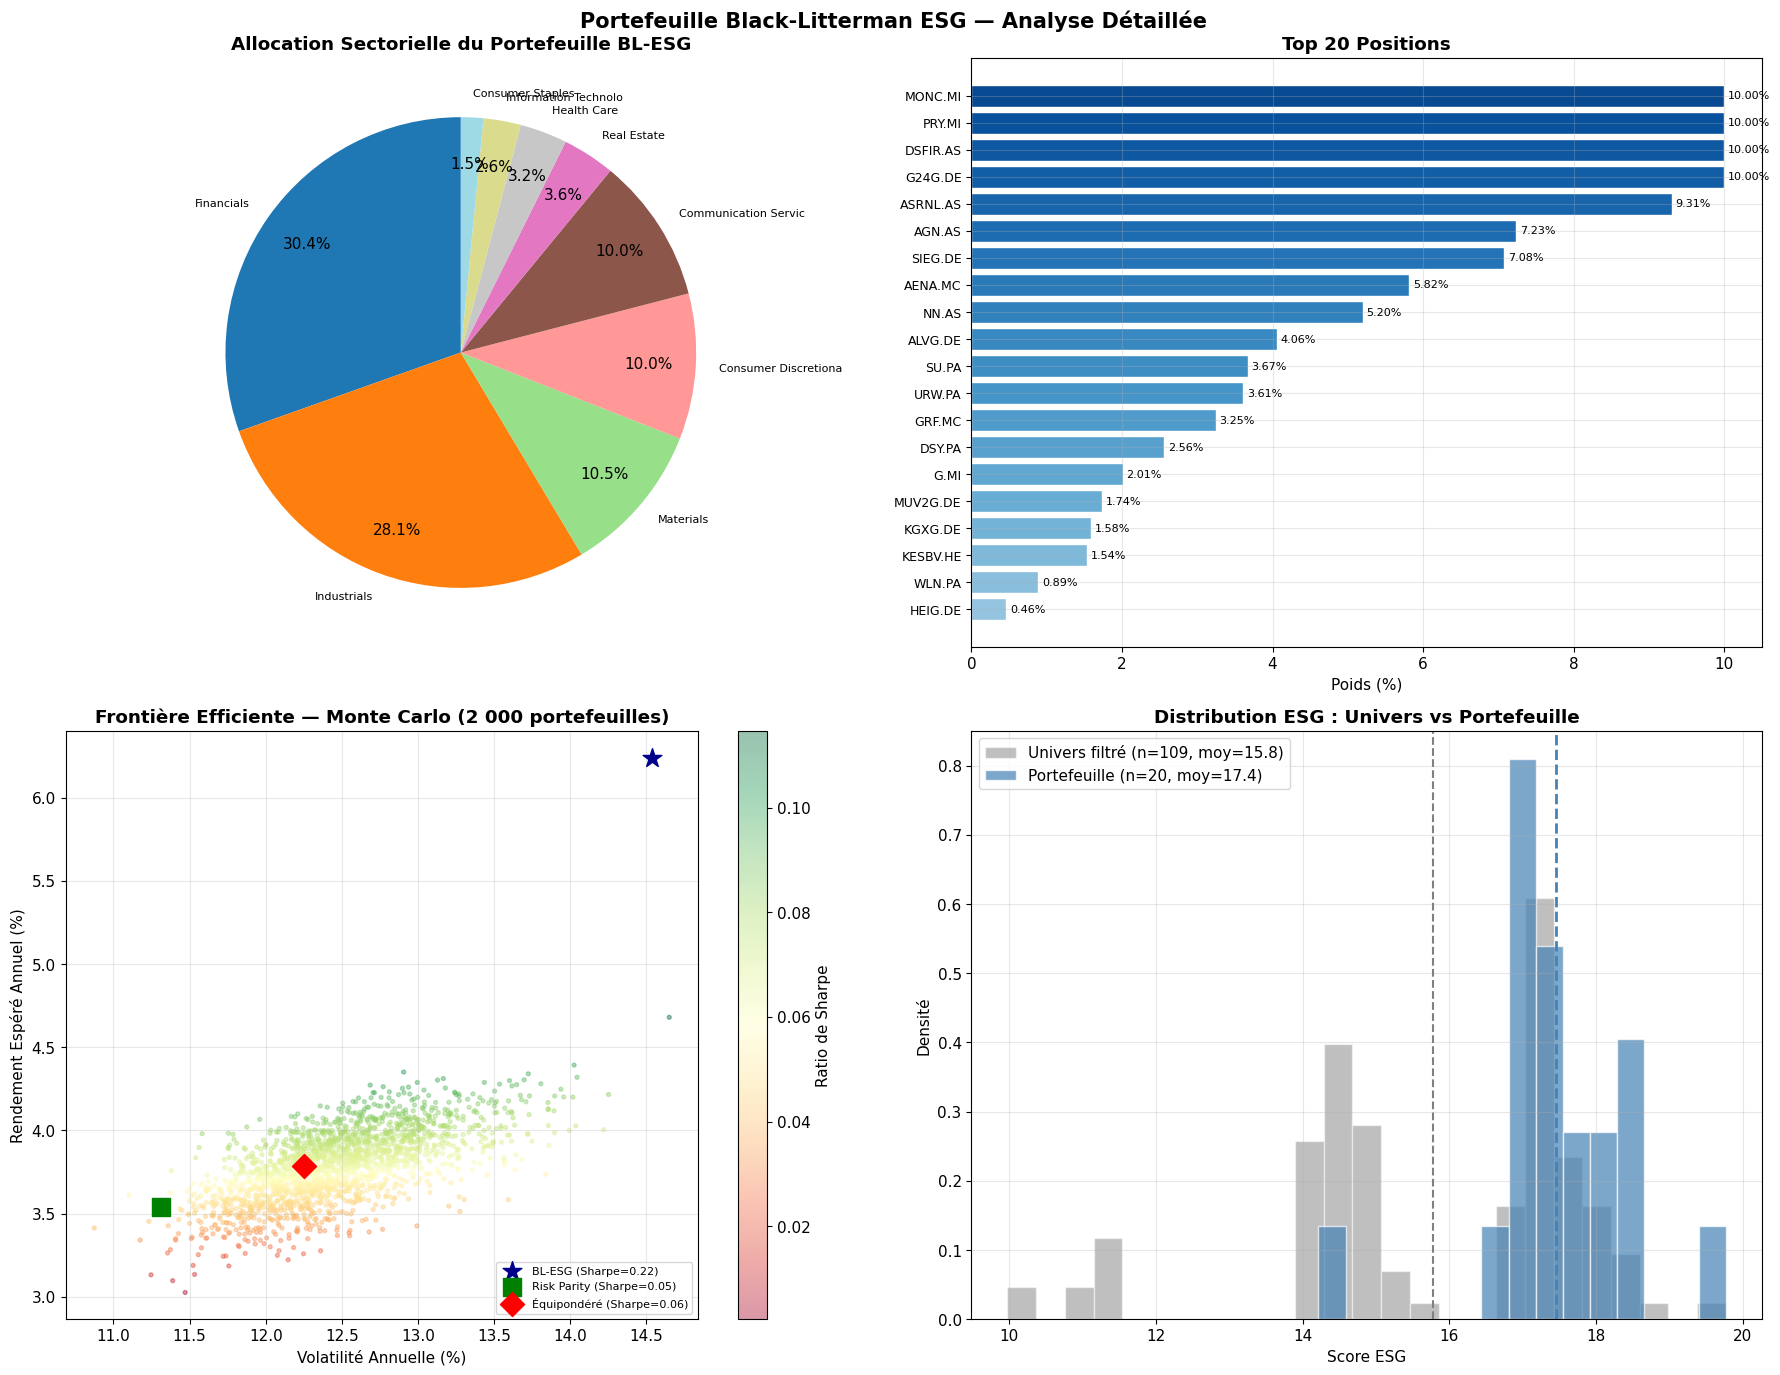

Graphique sauvegardé : P2_03_portefeuille_final.png


In [ ]:

# SECTION 5.1 — ANALYSE VISUELLE DU PORTEFEUILLE FINAL
#
# Quatre graphiques evaluent la qualite du portefeuille sous des angles
# complementaires : diversification, positionnement risque/rendement,
# et coherence entre allocation et convictions ESG.


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Portefeuille Black-Litterman ESG — Analyse Détaillée",
 fontsize=15, fontweight='bold')

# Graphique 1 : Repartition sectorielle
# Valide que le portefeuille est diversifie entre secteurs et non concentre


ax1 = axes[0, 0]
positions_info = univers_final_bl.loc[poids_final.index, ['SECTOR', 'NAME']].copy()
positions_info['POIDS'] = poids_final.values
alloc_sectorielle = positions_info.groupby('SECTOR')['POIDS'].sum().sort_values(ascending=False)
colors_secteurs = plt.cm.tab20(np.linspace(0, 1, len(alloc_sectorielle)))
wedges, texts, autotexts = ax1.pie(
 alloc_sectorielle.values,
 labels=[s[:20] for s in alloc_sectorielle.index],
 autopct='%1.1f%%', colors=colors_secteurs,
 pctdistance=0.8, startangle=90
)
for text in texts: text.set_fontsize(8)
ax1.set_title("Allocation Sectorielle du Portefeuille BL-ESG", fontweight='bold')

# Graphique 2 : Les 20 positions les plus importantes
# Identifie les convictions les plus fortes du modele BL-ESG


ax2 = axes[0, 1]
top20 = poids_final.head(20)
colors_pos = plt.cm.Blues(np.linspace(0.4, 0.9, len(top20)))[::-1]
bars = ax2.barh(range(len(top20)), top20.values * 100, color=colors_pos, edgecolor='white')
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20.index, fontsize=9)
ax2.set_xlabel("Poids (%)")
ax2.set_title("Top 20 Positions", fontweight='bold')
ax2.invert_yaxis()
for bar, val in zip(bars, top20.values * 100):
 ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=8)

# Graphique 3 : Frontiere efficiente Monte Carlo (2000 portefeuilles aleatoires)
# Positionne la strategie BL-ESG dans l'espace rendement/risque
# par rapport aux benchmarks et a l'ensemble des allocations possibles


ax3 = axes[1, 0]
n_sim = 2000
rendements_sim = np.zeros(n_sim)
volatilites_sim = np.zeros(n_sim)
sharpes_sim = np.zeros(n_sim)
np.random.seed(42)
for i in range(n_sim):
 w_sim = np.random.dirichlet(np.ones(N))
 rendements_sim[i] = w_sim @ mu_arr
 volatilites_sim[i] = np.sqrt(w_sim @ Sigma_arr @ w_sim)
 sharpes_sim[i] = (rendements_sim[i] - TAUX_SANS_RISQUE) / volatilites_sim[i]
scatter = ax3.scatter(volatilites_sim * 100, rendements_sim * 100,
 c=sharpes_sim, cmap='RdYlGn', alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax3, label='Ratio de Sharpe')
ax3.scatter(metriques_final['volatilite']*100, metriques_final['rendement']*100,
 color='darkblue', s=200, zorder=5, marker='*',
 label=f"BL-ESG (Sharpe={metriques_final['sharpe']:.2f})")
ax3.scatter(vp_rp*100, rp_rp*100, color='green', s=150, zorder=5, marker='s',
 label=f'Risk Parity (Sharpe={sh_rp:.2f})')
ax3.scatter(vp_eq*100, rp_eq*100, color='red', s=150, zorder=5, marker='D',
 label=f'Équipondéré (Sharpe={sh_eq:.2f})')
ax3.set_xlabel("Volatilité Annuelle (%)")
ax3.set_ylabel("Rendement Espéré Annuel (%)")
ax3.set_title("Frontière Efficiente — Monte Carlo (2 000 portefeuilles)", fontweight='bold')
ax3.legend(fontsize=8, loc='lower right')

# Graphique 4 : Distribution ESG de l'univers filtre vs du portefeuille
# Valide que les views ESG conduisent bien a sur-ponderer les leaders ESG


ax4 = axes[1, 1]
esg_scores_bl = esg_raw[tickers_bl].iloc[-1]
esg_portefeuille = esg_scores_bl[poids_final.index]
esg_univers = esg_scores_bl
ax4.hist(esg_univers.dropna(), bins=25, alpha=0.5, color='gray',
 label=f'Univers filtré (n={len(esg_univers)}, moy={esg_univers.mean():.1f})',
 edgecolor='white', density=True)
ax4.hist(esg_portefeuille.dropna(), bins=15, alpha=0.7, color='steelblue',
 label=f'Portefeuille (n={len(esg_portefeuille)}, moy={esg_portefeuille.mean():.1f})',
 edgecolor='white', density=True)
ax4.axvline(esg_univers.mean(), color='gray', linestyle='--', linewidth=1.5)
ax4.axvline(esg_portefeuille.mean(), color='steelblue', linestyle='--', linewidth=2)
ax4.set_xlabel("Score ESG")
ax4.set_ylabel("Densité")
ax4.set_title("Distribution ESG : Univers vs Portefeuille", fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig('P2_03_portefeuille_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : P2_03_portefeuille_final.png")

## Section 6 — Validation Walk-Forward sans biais lookahead


Fenetre de train : 2 ans glissants [t - 2 ans, t]
Fenetre de test : 1 mois ]t, t + 1 mois]

Rebalancement 1 : ---- TRAIN 2 ans ----|  -- TEST 1 mois --
Rebalancement 2 : ---- TRAIN 2 ans ----|  -- TEST 1 mois --
Rebalancement 3 : ---- TRAIN 2 ans ----|  -- TEST 1 mois --
...
```

A chaque rebalancement mensuel, on execute l'integralite du pipeline : filtrage ESG/ITR avec les notes disponibles a cette date, estimation de la covariance sur les 2 annees precedentes, calibration dynamique de l'alpha, construction des views composites avec le momentum ESG calcule sur les 6 derniers mois disponibles, optimisation du Sharpe. Les poids resultants sont alors appliques sur le mois suivant, qui est strictement hors echantillon.

### Pourquoi 2 ans de fenetre de train et 1 an de test ?

La fenetre de train de 2 ans (504 jours de bourse environ) offre un compromis entre deux contraintes opposees. Une fenetre trop courte produirait une estimation de covariance bruitee et instable, les rendements de quelques mois etant insuffisants pour capturer les structures de correlation de long terme. Une fenetre trop longue introduirait de la non-stationnarite : les regimes de marche et les correlations changent dans le temps, et une covariance estimee sur 5 ans ponderait egalement une periode de crise et une periode calme.

La fenetre de test de 1 an fournit un nombre suffisant de rebalancements mensuels (12 periodes) pour evaluer la consistance des resultats sans dependre d'une seule periode de marche.

### Ce que la validation walk-forward produit

A l'issue de la boucle, on dispose d'une serie de rendements journaliers hors echantillon couvrant la periode de test complete, sans aucun biais de lookahead. Ces rendements permettent de calculer des metriques de performance robustes (rendement annualise, ratio de Sharpe, drawdown maximum) qui sont directement comparables a ceux que la strategie produirait en production reelle.

In [ ]:

# SECTION 6 — BOUCLE WALK-FORWARD MENSUELLE
#
# A chaque iteration, on reconstruit integralement le portefeuille BL-ESG
# avec uniquement les donnees disponibles jusqu'a t_train_fin (inclus),
# puis on applique les poids sur la periode [t_train_fin, t_test_fin].
#
# ANNEES_TRAIN = 2 : fenetre d'estimation de 2 ans — compromis entre stabilite
#   de la covariance et reactivite aux changements de regime de marche.
# ANNEES_TEST  = 1 : 12 rebalancements mensuels — assez pour evaluer la
#   consistance de la strategie sur plusieurs regimes de marche.


ANNEES_TRAIN = 2
ANNEES_TEST  = 1

date_max       = price_raw.index.max()
date_debut_oos = date_max - pd.DateOffset(years=ANNEES_TEST)

# Generation des dates de rebalancement (fin de mois)
dates_rebal = pd.date_range(start=date_debut_oos, end=date_max, freq='ME')

print(f"Validation Walk-Forward")
print(f"  Fenetre de train        : {ANNEES_TRAIN} ans glissants")
print(f"  Periode de test (OOS)   : {date_debut_oos.date()} -> {date_max.date()}")
print(f"  Dates de rebalancement  : {len(dates_rebal) - 1} mois")
print()

# Structures de stockage des resultats de la boucle
# returns_oos_bl      : rendements journaliers BL-ESG hors echantillon
# returns_oos_eq      : rendements journaliers du benchmark equipondere
# historique_metriques: tableau de bord par rebalancement


returns_oos_bl       = []
returns_oos_eq       = []
historique_poids     = []
historique_metriques = []

#  BOUCLE WALK-FORWARD 
for i in range(len(dates_rebal) - 1):

    t_train_fin = dates_rebal[i]        # Derniere date de la fenetre de train
    t_test_fin  = dates_rebal[i + 1]    # Fin de la periode de test OOS

    print(f"  Rebalancement {i+1:02d} | Train -> {t_train_fin.date()} | "
          f"Test : {t_train_fin.date()} -> {t_test_fin.date()}", end="  ")

    # Construction du portefeuille avec les donnees disponibles jusqu'a t_train_fin.
    # La fonction garantit l'absence de lookahead : aucune donnee posterieure
    # a date_fin_train n'est consultee.
    poids_t, mu_BL_t, cov_t, tkrs_t, univ_t, met_t, alpha_t = construire_portefeuille(
        date_fin_train=t_train_fin,
        annees_train=ANNEES_TRAIN,
        verbose=False
    )

    if poids_t is None:
        print("Univers insuffisant, rebalancement ignore.")
        continue

    # Application des poids sur la periode de test hors echantillon.
    # Les tickers disponibles en OOS peuvent differer legerement de ceux du train.
    tickers_actifs = poids_t[poids_t > 0].index.tolist()
    tickers_oos    = [t for t in tickers_actifs if t in price_raw.columns]

    if len(tickers_oos) < 3:
        print("Pas assez de tickers OOS, ignore.")
        continue

    # Re-normalisation des poids sur les tickers effectivement disponibles en OOS.
    # Garantit que le portefeuille reste fully invested meme si quelques tickers
    # manquent de donnees de prix sur la periode de test.
    poids_oos = poids_t.reindex(tickers_oos).fillna(0)
    poids_oos = poids_oos / poids_oos.sum()

    # Recuperation des prix sur la periode de test
    prix_oos = price_raw.loc[t_train_fin:t_test_fin, tickers_oos].ffill().bfill()

    if len(prix_oos) < 2:
        print("Pas de donnees OOS, ignore.")
        continue

    # Calcul des rendements journaliers logarithmiques du portefeuille BL-ESG
    # et du benchmark equipondere sur la periode de test OOS
    ret_oos     = np.log(prix_oos / prix_oos.shift(1)).dropna()
    perf_bl_oos = (ret_oos * poids_oos.values).sum(axis=1)

    # Benchmark equipondere : meme univers de titres que BL-ESG pour la comparaison.
    # Ce benchmark est equitable car il beneficie du meme filtrage ESG/ITR.

    w_eq_oos    = np.ones(len(tickers_oos)) / len(tickers_oos)
    perf_eq_oos = (ret_oos * w_eq_oos).sum(axis=1)

    returns_oos_bl.append(perf_bl_oos)
    returns_oos_eq.append(perf_eq_oos)

    # Performance mensuelle et alpha du rebalancement courant.
    # L'alpha mensuel (BL - 1/N) mesure la valeur ajoutee des views ESG ce mois.

    perf_m_bl = (1 + perf_bl_oos).prod() - 1
    perf_m_eq = (1 + perf_eq_oos).prod() - 1

    # Score ESG pondere du portefeuille a cette date de rebalancement.
    # Permet de suivre le maintien du biais qualitatif ESG dans le temps.

    esg_t_scores = esg_raw.loc[:t_train_fin].iloc[-1]
    esg_pond_t   = sum(poids_oos.get(t, 0) * esg_t_scores.get(t, 0)
                       for t in tickers_oos)

    historique_metriques.append({
        'date_rebal'  : t_train_fin,
        'sharpe_train': met_t['sharpe'],
        'n_titres'    : len(tickers_oos),
        'perf_bl'     : perf_m_bl,
        'perf_eq'     : perf_m_eq,
        'alpha'       : perf_m_bl - perf_m_eq,
        'esg_pond'    : esg_pond_t,
        'alpha_calib' : alpha_t
    })

    historique_poids.append({'date': t_train_fin, 'poids': poids_oos.to_dict()})

    print(f"BL={perf_m_bl:+.2%}  1/N={perf_m_eq:+.2%}  "
          f"alpha={perf_m_bl - perf_m_eq:+.3%}  titres={len(tickers_oos)}")

# ── CONCATENATION DES RESULTATS 
# Les series mensuelles sont assemblees en une serie journaliere continue.
# Les doublons aux jonctions entre periodes sont supprimes.

if returns_oos_bl:
    series_bl_oos = pd.concat(returns_oos_bl).sort_index()
    series_eq_oos = pd.concat(returns_oos_eq).sort_index()
    series_bl_oos = series_bl_oos[~series_bl_oos.index.duplicated(keep='last')]
    series_eq_oos = series_eq_oos[~series_eq_oos.index.duplicated(keep='last')]
    df_hist       = pd.DataFrame(historique_metriques).set_index('date_rebal')
    print(f"\nWalk-forward termine : {len(dates_rebal) - 1} rebalancements "
          f"| {len(series_bl_oos)} jours OOS")
else:
    print("\nAucune periode OOS produite.")
    print("Lancez le diagnostic ci-dessous pour identifier la cause.")

Validation Walk-Forward
  Fenetre de train        : 2 ans glissants
  Periode de test (OOS)   : 2024-12-31 -> 2025-12-31
  Dates de rebalancement  : 12 mois

  Rebalancement 01 | Train -> 2024-12-31 | Test : 2024-12-31 -> 2025-01-31  BL=+5.89%  1/N=+6.32%  alpha=-0.434%  titres=18
  Rebalancement 02 | Train -> 2025-01-31 | Test : 2025-01-31 -> 2025-02-28  BL=+3.33%  1/N=+1.81%  alpha=+1.522%  titres=18
  Rebalancement 03 | Train -> 2025-02-28 | Test : 2025-02-28 -> 2025-03-31  BL=-1.16%  1/N=-2.32%  alpha=+1.152%  titres=21
  Rebalancement 04 | Train -> 2025-03-31 | Test : 2025-03-31 -> 2025-04-30  BL=-0.54%  1/N=-1.99%  alpha=+1.445%  titres=20
  Rebalancement 05 | Train -> 2025-04-30 | Test : 2025-04-30 -> 2025-05-31  BL=+7.38%  1/N=+6.91%  alpha=+0.463%  titres=21
  Rebalancement 06 | Train -> 2025-05-31 | Test : 2025-05-31 -> 2025-06-30  BL=-0.86%  1/N=-1.75%  alpha=+0.890%  titres=21
  Rebalancement 07 | Train -> 2025-06-30 | Test : 2025-06-30 -> 2025-07-31  BL=+2.93%  1/N=+3.41% 

## Section 6.1 — Analyse des Resultats Hors Echantillon

Cette section produit le tableau de bord quantitatif de la validation walk-forward. Les metriques calculees ici sont celles qui comptent pour evaluer une strategie avant mise en production, car elles sont calculees sur des donnees que le modele n'a jamais vues lors de l'optimisation.

### Metriques de performance

**Rendement annualise OOS :** le rendement moyen journalier multiplie par 252. C'est la mesure de base de la rentabilite de la strategie sur la periode de test.

**Volatilite annualisee OOS :** l'ecart-type des rendements journaliers multiplie par la racine de 252. Mesure le risque realise de la strategie, c'est-a-dire l'incertitude effective des rendements en production.

**Ratio de Sharpe OOS :** (rendement annualise - taux sans risque) / volatilite annualisee. C'est la metrique de reference en gestion de portefeuille — elle normalise la performance par le risque pris. Un Sharpe superieur a 0.5 est generalement considere comme acceptable; superieur a 1 est excellent.

**Drawdown maximum OOS :** la perte maximale depuis un pic de performance. C'est une metrique de risque extreme critique pour evaluer la resistance de la strategie aux periodes de stress de marche. Un drawdown inferieur a 20% est generalement acceptable pour un portefeuille actions.

**Alpha annualise (BL vs 1/N) :** la surperformance annualisee de la strategie BL-ESG par rapport au benchmark equipondere. C'est la mesure directe de la valeur ajoutee des views ESG. Un alpha positif et consistant d'un mois sur l'autre constitue la preuve empirique que les scores ESG apportent de l'information predictive sur les rendements futurs.

**Pourcentage de mois positifs :** la proportion de rebalancements ou BL-ESG surperforme 1/N. Une proportion superieure a 50% indique une surperformance reguliere et non concentree sur quelques mois exceptionnels.

In [ ]:

# SECTION 6.1 — CALCUL DES METRIQUES DE PERFORMANCE HORS ECHANTILLON
#
# Toutes les metriques sont calculees sur la serie de rendements OOS :
# cette serie est strictement hors echantillon — le modele ne l'a jamais
# vue pendant la phase de construction des poids.
#
# La concatenation des series mensuelles est effectuee ici pour garantir
# que cette cellule reste autonome, independamment de l'ordre d'execution
# des cellules dans le notebook.


# Verification que la boucle walk-forward a bien produit des resultats
if not returns_oos_bl:
    raise ValueError(
        "La liste returns_oos_bl est vide. "
        "Verifiez que la boucle walk-forward (cellule precedente) "
        "s'est executee correctement et a produit au moins une periode OOS."
    )

# Concatenation des series de rendements mensuels en une serie journaliere continue.
# Les doublons aux jonctions entre periodes sont supprimes en conservant
# la derniere occurrence, ce qui evite de double-compter le dernier jour d'un mois.


series_bl_oos = pd.concat(returns_oos_bl).sort_index()
series_eq_oos = pd.concat(returns_oos_eq).sort_index()
series_bl_oos = series_bl_oos[~series_bl_oos.index.duplicated(keep='last')]
series_eq_oos = series_eq_oos[~series_eq_oos.index.duplicated(keep='last')]

# Construction du tableau de bord mensuel a partir de l'historique des rebalancements
df_hist = pd.DataFrame(historique_metriques).set_index('date_rebal')


def max_drawdown(returns):
    """
    Calcule le drawdown maximum d'une serie de rendements journaliers.
    Le drawdown a chaque date est defini comme la perte depuis le plus haut
    historique : (valeur_courante - valeur_pic) / valeur_pic.
    Le drawdown maximum est la valeur la plus negative de cette serie.
    """
    cumul       = (1 + returns).cumprod()
    rolling_max = cumul.cummax()
    drawdown    = (cumul - rolling_max) / rolling_max
    return drawdown.min()


# Calcul des performances cumulees et metriques annualisees sur toute la periode OOS

cumul_bl_oos = (1 + series_bl_oos).cumprod()
cumul_eq_oos = (1 + series_eq_oos).cumprod()

perf_cumul_bl = cumul_bl_oos.iloc[-1] - 1
perf_cumul_eq = cumul_eq_oos.iloc[-1] - 1
rend_ann_bl   = series_bl_oos.mean() * JOURS_TRADING
rend_ann_eq   = series_eq_oos.mean() * JOURS_TRADING
vol_ann_bl    = series_bl_oos.std()  * np.sqrt(JOURS_TRADING)
vol_ann_eq    = series_eq_oos.std()  * np.sqrt(JOURS_TRADING)
sharpe_oos_bl = (rend_ann_bl - TAUX_SANS_RISQUE) / vol_ann_bl if vol_ann_bl > 0 else 0
sharpe_oos_eq = (rend_ann_eq - TAUX_SANS_RISQUE) / vol_ann_eq if vol_ann_eq > 0 else 0
mdd_bl        = max_drawdown(series_bl_oos)
mdd_eq        = max_drawdown(series_eq_oos)
alpha_ann     = rend_ann_bl - rend_ann_eq


print(f"Periode OOS : {series_bl_oos.index.min().date()} -> {series_bl_oos.index.max().date()}")
print(f"Rebalancements effectues : {len(df_hist)}")

print(f"\n{'='*65}")


print(f"  RESULTATS WALK-FORWARD — HORS ECHANTILLON (OOS)")
print(f"{'='*65}")
print(f"  {'Metrique':<35} {'BL-ESG':>12}  {'1/N':>12}")
print(f"  {'-'*60}")
print(f"  {'Performance cumulee OOS':<35} {perf_cumul_bl*100:>+11.2f}%  {perf_cumul_eq*100:>+11.2f}%")
print(f"  {'Rendement annualise OOS':<35} {rend_ann_bl*100:>+11.2f}%  {rend_ann_eq*100:>+11.2f}%")
print(f"  {'Volatilite annualisee OOS':<35} {vol_ann_bl*100:>11.2f}%  {vol_ann_eq*100:>11.2f}%")
print(f"  {'Ratio de Sharpe OOS':<35} {sharpe_oos_bl:>12.3f}  {sharpe_oos_eq:>12.3f}")
print(f"  {'Drawdown Maximum OOS':<35} {mdd_bl*100:>11.2f}%  {mdd_eq*100:>11.2f}%")
print(f"  {'-'*60}")
print(f"  {'Alpha annualise (BL vs 1/N)':<35} {alpha_ann*100:>+11.2f}%")
print(f"  {'Alpha mensuel moyen':<35} {df_hist['alpha'].mean()*100:>+11.3f}%")
print(f"  {'% mois BL > 1/N':<35} {(df_hist['alpha'] > 0).mean()*100:>11.1f}%")
print(f"  {'Score ESG moyen (pondere)':<35} {df_hist['esg_pond'].mean():>12.2f}")
print(f"  {'Nb titres moyen / rebalancement':<35} {df_hist['n_titres'].mean():>12.1f}")
print(f"{'='*65}")


print(f"\n  Detail par rebalancement :")
print(f"  {'Date':<12} {'Sharpe train':>13} {'Titres':>7} {'Perf BL':>9} "
      f"{'Perf 1/N':>9} {'Alpha':>8} {'ESG pond.':>10}")
print(f"  {'-'*70}")
for date, row in df_hist.iterrows():
    print(f"  {str(date.date()):<12} {row['sharpe_train']:>13.3f} {int(row['n_titres']):>7} "
          f"{row['perf_bl']*100:>+8.2f}%  {row['perf_eq']*100:>+8.2f}%  "
          f"{row['alpha']*100:>+7.3f}%  {row['esg_pond']:>10.2f}")

Periode OOS : 2025-01-02 -> 2025-12-31
Rebalancements effectues : 12

  RESULTATS WALK-FORWARD — HORS ECHANTILLON (OOS)
  Metrique                                  BL-ESG           1/N
  ------------------------------------------------------------
  Performance cumulee OOS                  +22.74%       +14.48%
  Rendement annualise OOS                  +21.45%       +14.70%
  Volatilite annualisee OOS                 15.44%        16.30%
  Ratio de Sharpe OOS                        1.195         0.718
  Drawdown Maximum OOS                     -15.14%       -16.66%
  ------------------------------------------------------------
  Alpha annualise (BL vs 1/N)               +6.75%
  Alpha mensuel moyen                      +0.578%
  % mois BL > 1/N                            66.7%
  Score ESG moyen (pondere)                  17.53
  Nb titres moyen / rebalancement             20.1

  Detail par rebalancement :
  Date          Sharpe train  Titres   Perf BL  Perf 1/N    Alpha  ESG pond.
  

## Section 6.2 — Visualisation des Resultats Walk-Forward

Les quatre graphiques suivants constituent le tableau de bord visuel de la validation. Ils permettent de repondre aux questions critiques qu'un allocataire ou un comite d'investissement poserait avant d'approuver la strategie.

**Graphique 1 — Performances cumulees OOS :**
Ce graphique est la representation la plus directe de la performance de la strategie. La zone verte entre les deux courbes indique les periodes ou BL-ESG surperforme le benchmark equipondere ; la zone rouge les periodes de sous-performance. Les lignes verticales pointillees marquent chaque date de rebalancement mensuel. L'observation de ce graphique permet de juger si la surperformance est reguliere ou concentree sur quelques periodes.

**Graphique 2 — Profil de drawdown :**
Le drawdown est la metrique de risque "vecu" par un investisseur reel. Une courbe de drawdown qui ne descend jamais en dessous de -15% signifie qu'un investisseur n'aurait jamais perdu plus de 15% depuis son dernier point haut. Ce graphique permet d'evaluer si le profil de risque de la strategie est acceptable pour les mandataires cibles.

**Graphique 3 — Alpha mensuel par rebalancement :**
Ce graphique en barres decompose la surperformance mois par mois. Une majorite de barres bleues (alpha positif) indique une surperformance consistante des views ESG. La ligne en pointilles represente l'alpha moyen. Ce graphique revele si la surperformance est reguliere ou concentree sur quelques mois exceptionnels — une surperformance reguliere est plus robuste et plus commercialisable.

**Graphique 4 — Score ESG pondere dans le temps :**
Ce dernier graphique suit l'evolution du score ESG moyen pondere du portefeuille a travers les rebalancements, compare a la moyenne de l'univers filtre. Il valide que la strategie maintient un biais qualitatif ESG consistant dans le temps, meme quand l'optimisation financiere guide les poids. Un portefeuille systematiquement au-dessus de la moyenne de l'univers confirme la double nature de la strategie : financiere et extra-financiere.

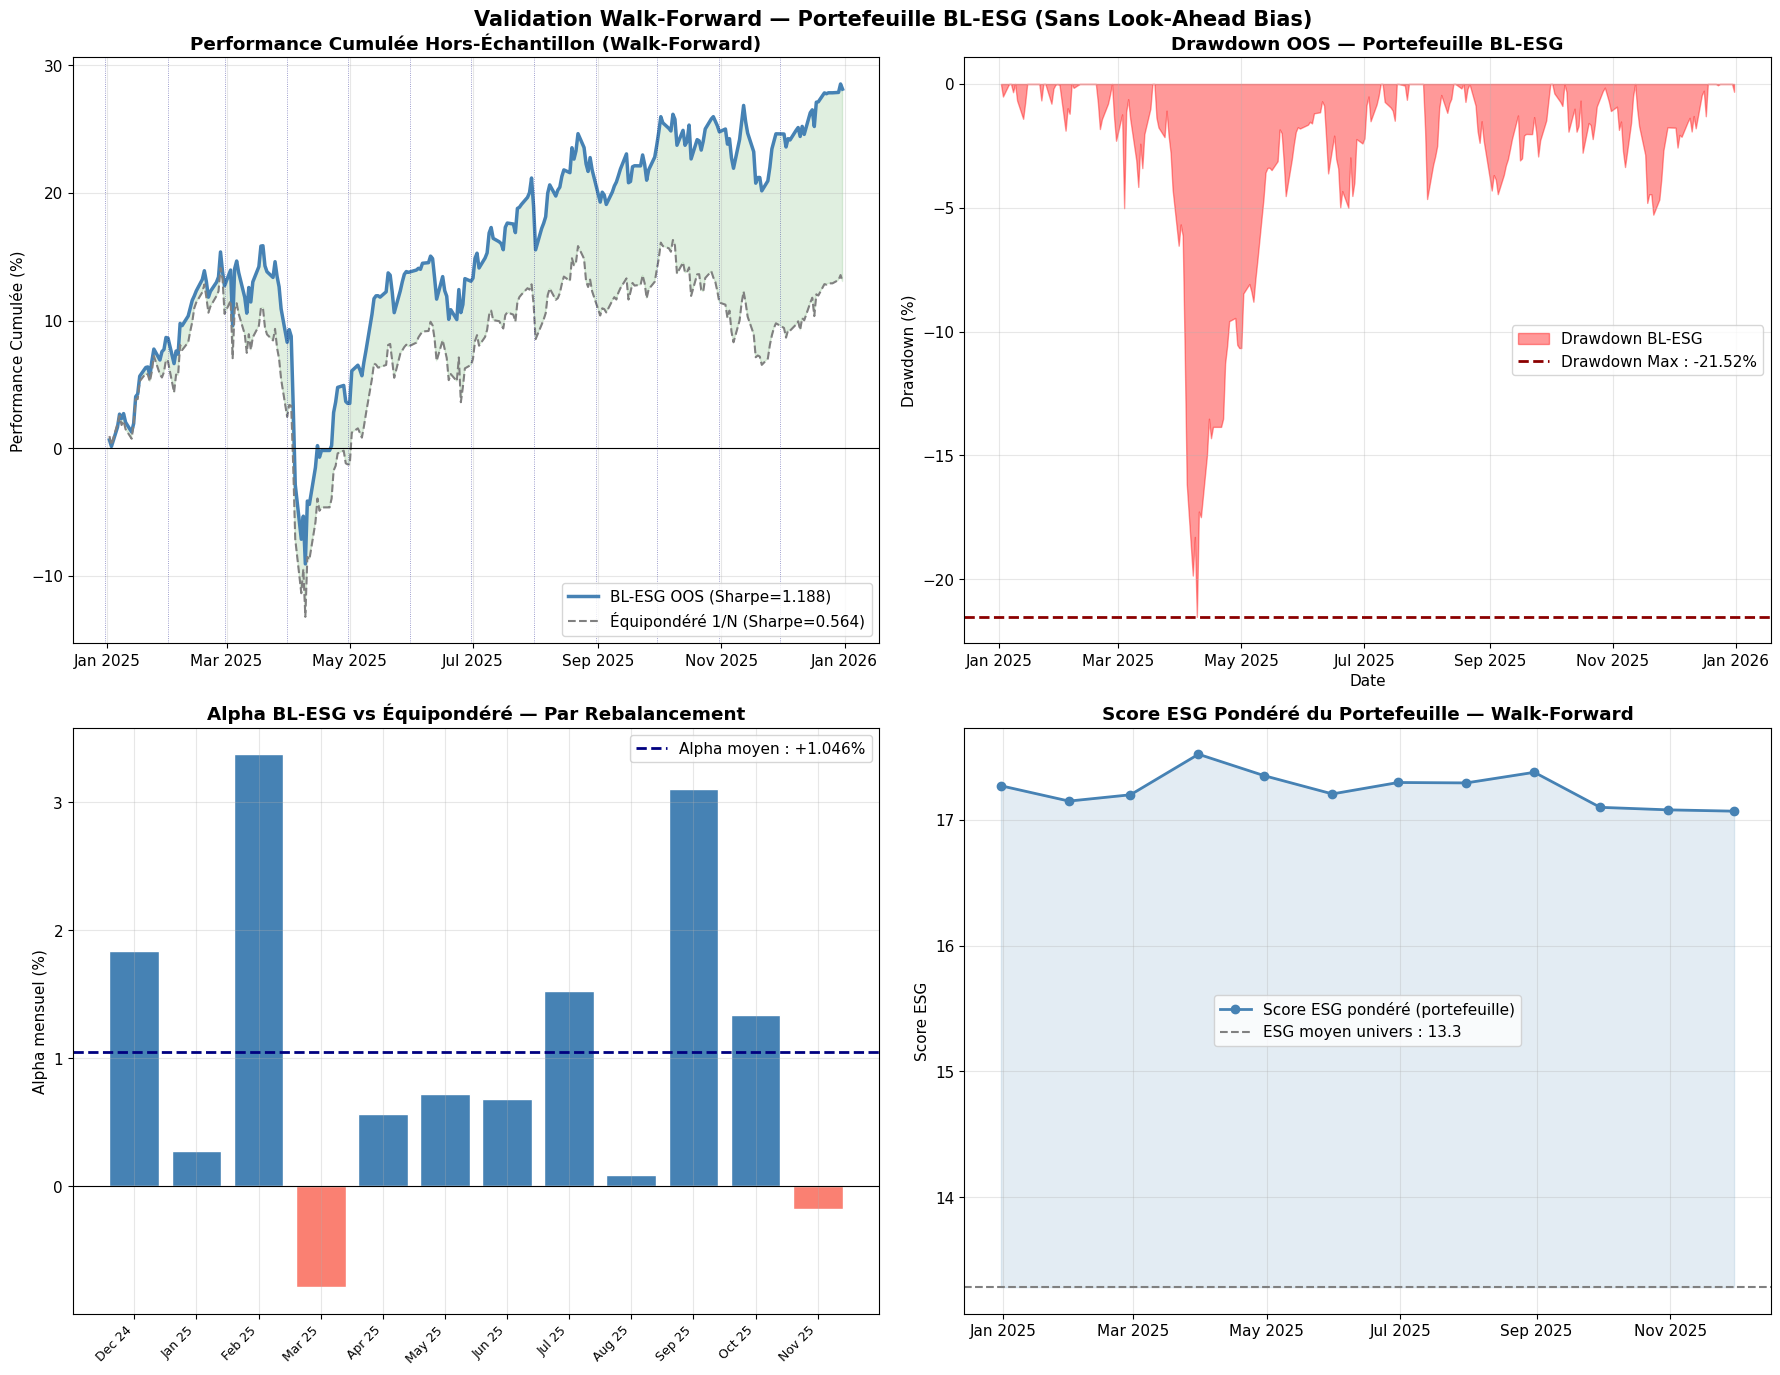

✅ Graphique sauvegardé : P2_04_walkforward_resultats.png


In [ ]:

# SECTION 6.2 — VISUALISATION DES RESULTATS HORS ECHANTILLON
#
# Quatre graphiques constituent le tableau de bord de la validation.
# Ils permettent d'evaluer la strategie sur les dimensions cles : performance
# cumulee, profil de risque, regularite de l'alpha et qualite ESG dans le temps.


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Validation Walk-Forward — Portefeuille BL-ESG (Sans Look-Ahead Bias)",
 fontsize=15, fontweight='bold')

# Graphique 1 : Performances cumulees BL-ESG vs benchmark equipondere
# Les zones colorees montrent les periodes de sur/sous-performance relative
# Les lignes verticales marquent chaque date de rebalancement mensuel
ax1 = axes[0, 0]
ax1.plot(cumul_bl_oos.index, (cumul_bl_oos - 1) * 100,
 color='steelblue', linewidth=2.5,
 label=f'BL-ESG OOS (Sharpe={sharpe_oos_bl:.3f})')
ax1.plot(cumul_eq_oos.index, (cumul_eq_oos - 1) * 100,
 color='gray', linewidth=1.5, linestyle='--',
 label=f'Équipondéré 1/N (Sharpe={sharpe_oos_eq:.3f})')
ax1.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax1.fill_between(cumul_bl_oos.index,
 (cumul_bl_oos - 1) * 100, (cumul_eq_oos - 1) * 100,
 where=(cumul_bl_oos >= cumul_eq_oos), alpha=0.12, color='green')
ax1.fill_between(cumul_bl_oos.index,
 (cumul_bl_oos - 1) * 100, (cumul_eq_oos - 1) * 100,
 where=(cumul_bl_oos < cumul_eq_oos), alpha=0.12, color='red')
# Marqueurs de rebalancement
for date in df_hist.index:
 ax1.axvline(date, color='navy', linestyle=':', linewidth=0.6, alpha=0.5)
ax1.set_ylabel("Performance Cumulée (%)")
ax1.set_title("Performance Cumulée Hors-Échantillon (Walk-Forward)", fontweight='bold')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Graphique 2 : Profil de drawdown de la strategie BL-ESG
# Mesure la perte maximale depuis le dernier pic — indicateur de risque extreme

ax2 = axes[0, 1]
rolling_max_bl = cumul_bl_oos.cummax()
drawdown_bl = (cumul_bl_oos - rolling_max_bl) / rolling_max_bl * 100
ax2.fill_between(drawdown_bl.index, drawdown_bl.values, 0,
 color='red', alpha=0.4, label='Drawdown BL-ESG')
ax2.axhline(mdd_bl * 100, color='darkred', linestyle='--', linewidth=2,
 label=f'Drawdown Max : {mdd_bl*100:.2f}%')
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
ax2.set_title("Drawdown OOS — Portefeuille BL-ESG", fontweight='bold')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Graphique 3 : Alpha mensuel decompose par rebalancement
# Permet d'evaluer la regularite de la surperformance des views ESG


ax3 = axes[1, 0]
colors_alpha = ['steelblue' if a >= 0 else 'salmon' for a in df_hist['alpha'].values]
bars_alpha = ax3.bar(range(len(df_hist)), df_hist['alpha'].values * 100,
 color=colors_alpha, edgecolor='white')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.axhline(df_hist['alpha'].mean() * 100, color='navy', linestyle='--', linewidth=2,
 label=f"Alpha moyen : {df_hist['alpha'].mean()*100:+.3f}%")
ax3.set_xticks(range(len(df_hist)))
ax3.set_xticklabels([d.strftime('%b %y') for d in df_hist.index],
 rotation=45, ha='right', fontsize=9)
ax3.set_ylabel("Alpha mensuel (%)")
ax3.set_title("Alpha BL-ESG vs Équipondéré — Par Rebalancement", fontweight='bold')
ax3.legend()

# Graphique 4 : Maintien du biais qualitatif ESG dans le temps
# Valide que la strategie reste coherente avec ses objectifs extra-financiers
# a travers l'ensemble des rebalancements de la periode de test


ax4 = axes[1, 1]
esg_univ_moy = esg_raw.loc[date_debut_oos:date_max].mean(axis=1).mean()
ax4.plot(df_hist.index, df_hist['esg_pond'],
 color='steelblue', linewidth=2, marker='o', markersize=6,
 label='Score ESG pondéré (portefeuille)')
ax4.axhline(esg_univ_moy, color='gray', linestyle='--', linewidth=1.5,
 label=f'ESG moyen univers : {esg_univ_moy:.1f}')
ax4.fill_between(df_hist.index, df_hist['esg_pond'], esg_univ_moy,
 alpha=0.15, color='steelblue')
ax4.set_ylabel("Score ESG")
ax4.set_title("Score ESG Pondéré du Portefeuille — Walk-Forward", fontweight='bold')
ax4.legend()
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('P2_04_walkforward_resultats.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : P2_04_walkforward_resultats.png")

## Section 7 — Rapport Final, Allocation Detaillee 

Cette derniere section consolide l'ensemble des resultats en un rapport de synthese structure, produit la visualisation complete de l'allocation du portefeuille final, et exporte les donnees dans des formats utilisables pour la mise en production ou pour un reporting aux mandataires.


### Graphique d'allocation detaille

Le graphique final presente trois lectures complementaires du portefeuille :

- Le premier panneau montre les poids de toutes les positions, colores par score ESG. Un gradient du rouge (faibles scores ESG) vers le vert (scores eleves) permet de visualiser immediatement si les plus grosses positions correspondent bien aux meilleurs scores ESG — ce qui validerait la coherence des views BL.

- Le second panneau est le camembert sectoriel, essentiel pour communiquer l'allocation a un comite d'investissement.

- Le troisieme panneau est un nuage de points poids versus score ESG avec une droite de tendance. Une pente positive confirme que les views ESG ont bien oriente les poids vers les leaders extra-financiers : c'est la preuve visuelle que la strategie fait ce qu'elle promet.

### Exports CSV

Trois fichiers sont exportes pour assurer la tracabilite et permettre une mise en production :

- **P2_portefeuille_BL_ESG_final.csv** : la composition complete du portefeuille avec poids, scores ESG, ITR et rendements BL pour chaque titre.
- **P2_rendements_oos.csv** : la serie de rendements journaliers OOS pour BL-ESG et le benchmark, utilisable pour des analyses de risque complementaires.
- **P2_historique_rebalancements.csv** : le tableau de bord mensuel de la validation walk-forward.

RAPPORT FINAL — PARTIE 2

Composition du portefeuille final :
  TICKER  POIDS_PCT                        NOM                SECTEUR        PAYS  SCORE_ESG  ITR_C  RENDEMENT_BL  MU_BL_PCT
 MONC.MI    10.0000                MONCLER SPA Consumer Discretionary       Italy    18.5100 1.7000        6.6600     6.6560
  PRY.MI    10.0000               PRYSMIAN SPA            Industrials       Italy    16.9200 1.3000        7.8000     7.7990
DSFIR.AS    10.0000           DSM-FIRMENICH AG              Materials Netherlands    17.2400 1.8000        5.5400     5.5450
 G24G.DE    10.0000                 SCOUT24 SE Communication Services     Germany    17.3700 1.5000        5.8500     5.8500
ASRNL.AS     9.3053           ASR NEDERLAND NV             Financials Netherlands    17.7100 1.7000        5.8800     5.8780
  AGN.AS     7.2349                  AEGON LTD             Financials Netherlands    17.0800 1.5000        6.6000     6.6010
 SIEG.DE     7.0773             SIEMENS AG-REG            Indus

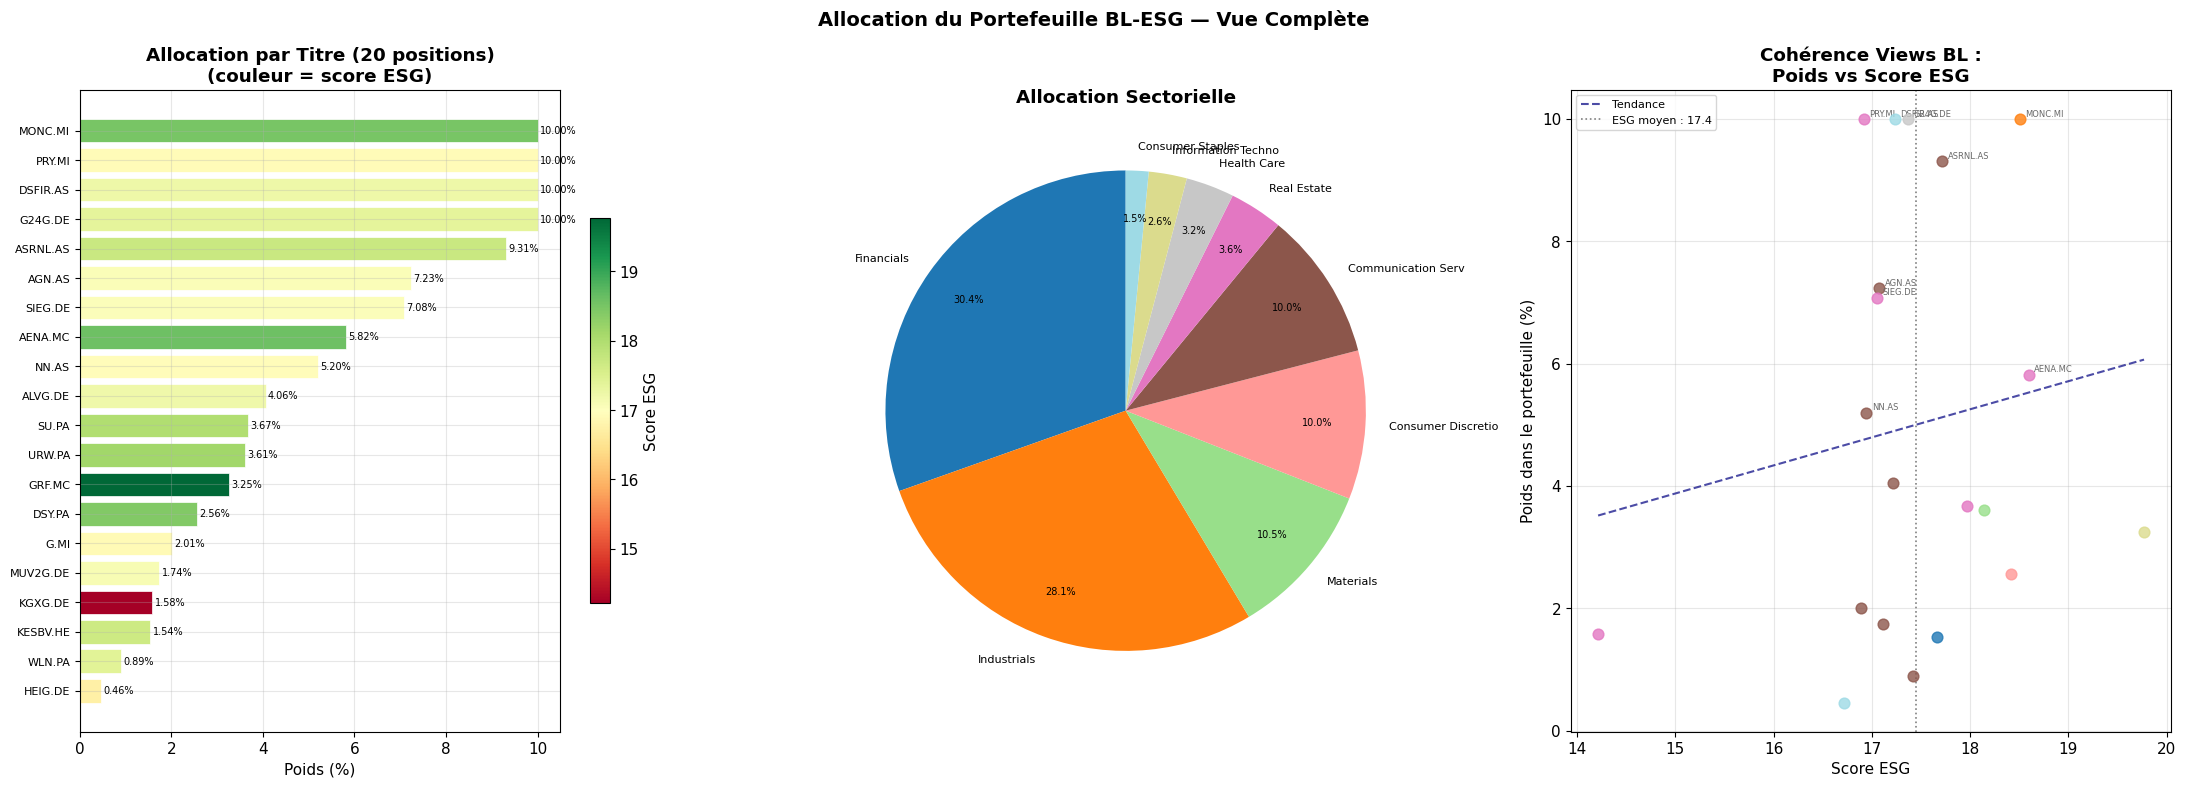

Graphique sauvegardé : P2_05_allocation_portefeuille.png

 Exports CSV :
P2_portefeuille_BL_ESG_final.csv — composition du portefeuille final
P2_rendements_oos.csv — rendements journaliers OOS
P2_historique_rebalancements.csv — métriques par rebalancement

 PARTIE 2 TERMINÉE


In [ ]:

# SECTION 7 — RAPPORT FINAL, ALLOCATION DETAILLEE ET EXPORTS
#
# Cette cellule produit :
# (1) Le rapport de synthese consolide (metriques financieres et ESG)
# (2) Le graphique complet d'allocation du portefeuille final (3 panneaux)
# (3) Trois fichiers CSV pour la mise en production et le reporting


print("=" * 70)
print("RAPPORT FINAL — PARTIE 2")
print("=" * 70)

# Calcul des metriques ESG agregees du portefeuille
# Ces metriques pondereront les scores individuels par les poids du portefeuille
# et constitueront les indicateurs de reporting extra-financier


esg_scores_final_dict = esg_raw[tickers_bl].iloc[-1].to_dict()
score_esg_pond = sum(poids_final[t] * esg_scores_final_dict.get(t, 0)
 for t in poids_final.index)
itr_pond = sum(poids_final[t] * univers_final_bl.loc[t, 'ITR']
 for t in poids_final.index if t in univers_final_bl.index)

# Construction du tableau de reporting institutionnel
# Ce tableau contient l'information complete pour un reporting aux mandataires


rapport = pd.DataFrame({
 'TICKER' : poids_final.index,
 'POIDS_PCT' : (poids_final.values * 100).round(4),
 'NOM' : [name_map.get(t, '?') for t in poids_final.index],
 'SECTEUR' : [univers_final_bl.loc[t, 'SECTOR'] if t in univers_final_bl.index else '?'
 for t in poids_final.index],
 'PAYS' : [univers_final_bl.loc[t, 'COUNTRY'] if t in univers_final_bl.index else '?'
 for t in poids_final.index],
 'SCORE_ESG' : [round(esg_scores_final_dict.get(t, float('nan')), 2)
 for t in poids_final.index],
 'ITR_C' : [round(univers_final_bl.loc[t, 'ITR'], 2)
 if t in univers_final_bl.index else float('nan')
 for t in poids_final.index],
 'RENDEMENT_BL': [round(mu_BL[t] * 100, 2) for t in poids_final.index],
 'MU_BL_PCT' : [round(mu_BL[t] * 100, 3) for t in poids_final.index],
})

print("\nComposition du portefeuille final :")
print(rapport.to_string(index=False))

print(f"\n{'='*70}")
print(f" MÉTRIQUES ESG AGRÉGÉES DU PORTEFEUILLE")
print(f"{'='*70}")
print(f" Score ESG pondéré (moyen) : {score_esg_pond:.2f}")
print(f" ITR pondéré (°C) : {itr_pond:.3f}°C")
print(f" % portefeuille aligné 2°C : 100% (par construction)")
print(f" Nb de titres : {len(poids_final)}")
print(f" Nb de secteurs représentés : {rapport['SECTEUR'].nunique()}")
print(f" Pays représentés : {rapport['PAYS'].nunique()}")
print(f"{'='*70}")
print(f" MÉTRIQUES FINANCIÈRES (EX-ANTE — DONNÉES COMPLÈTES)")
print(f"{'='*70}")
print(f" Rendement espéré (BL) : {metriques_final['rendement']*100:.2f}% / an")
print(f" Volatilité : {metriques_final['volatilite']*100:.2f}% / an")
print(f" Ratio de Sharpe : {metriques_final['sharpe']:.3f}")
print(f" Alpha calibré dynamiquement : {alpha_final*100:.2f}% / an")
print(f" Concentration (HHI) : {(poids_final**2).sum():.4f} (1/N={1/len(poids_final):.4f})")
print(f"{'='*70}")
print(f" MÉTRIQUES WALK-FORWARD (HORS ÉCHANTILLON — OOS)")
print(f"{'='*70}")
print(f" Période OOS : {series_bl_oos.index.min().date()} → {series_bl_oos.index.max().date()}")
print(f" Rendement annualisé OOS : {rend_ann_bl*100:.2f}% / an")
print(f" Volatilité OOS : {vol_ann_bl*100:.2f}% / an")
print(f" Ratio de Sharpe OOS : {sharpe_oos_bl:.3f}")
print(f" Drawdown Maximum OOS : {mdd_bl*100:.2f}%")
print(f" Alpha vs 1/N (annualisé) : {alpha_ann*100:+.2f}%")
print(f" % mois BL > 1/N : {(df_hist['alpha'] > 0).mean()*100:.1f}%")
print(f" Alpha calibré moyen (OOS) : {df_hist['alpha_calib'].mean()*100:.2f}%")
print(f"{'='*70}")


# GRAPHIQUE D'ALLOCATION DU PORTEFEUILLE FINAL
#
# Ce graphique en trois panneaux constitue la page d'allocation du rapport.
# Il est concu pour etre directement utilisable dans un document de presentation
# a un comite d'investissement ou a des mandataires institutionnels.




fig, axes = plt.subplots(1, 3, figsize=(22, max(8, len(poids_final) * 0.35)))
fig.suptitle("Allocation du Portefeuille BL-ESG — Vue Complète",
 fontsize=14, fontweight='bold')

# Panneau 1 : Tous les poids colores par score ESG
# Le gradient rouge/vert permet de verifier visuellement que les plus grosses
# positions correspondent bien aux scores ESG les plus eleves (coherence des views)


ax1 = axes[0]
esg_vals = [esg_scores_final_dict.get(t, 50) for t in poids_final.index]
norm_esg = plt.Normalize(vmin=min(esg_vals), vmax=max(esg_vals))
cmap_esg = plt.cm.RdYlGn
colors_t = [cmap_esg(norm_esg(e)) for e in esg_vals]

bars = ax1.barh(range(len(poids_final)), poids_final.values * 100,
 color=colors_t, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(poids_final)))
ax1.set_yticklabels(poids_final.index, fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel("Poids (%)")
ax1.set_title(f"Allocation par Titre ({len(poids_final)} positions)\n(couleur = score ESG)",
 fontweight='bold')
for bar, val in zip(bars, poids_final.values * 100):
 ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
 f'{val:.2f}%', va='center', fontsize=7)
# Colorbar pour le score ESG
sm = plt.cm.ScalarMappable(cmap=cmap_esg, norm=norm_esg)
sm.set_array([])
plt.colorbar(sm, ax=ax1, label='Score ESG', shrink=0.6)

# Panneau 2 : Allocation sectorielle
# Format standard pour la communication a un comite d'investissement


ax2 = axes[1]
positions_info = univers_final_bl.loc[poids_final.index, ['SECTOR', 'NAME']].copy()
positions_info['POIDS'] = poids_final.values
alloc_sectorielle = positions_info.groupby('SECTOR')['POIDS'].sum().sort_values(ascending=False)
colors_secteurs = plt.cm.tab20(np.linspace(0, 1, len(alloc_sectorielle)))
wedges, texts, autotexts = ax2.pie(
 alloc_sectorielle.values,
 labels=[s[:18] for s in alloc_sectorielle.index],
 autopct='%1.1f%%',
 colors=colors_secteurs,
 pctdistance=0.80,
 startangle=90
)
for text in texts: text.set_fontsize(8)
for autotext in autotexts: autotext.set_fontsize(7)
ax2.set_title("Allocation Sectorielle", fontweight='bold')

# Panneau 3 : Nuage de points poids vs score ESG avec droite de tendance
# Une pente positive de la droite de tendance est la preuve empirique que
# les views BL-ESG ont bien alloue davantage de capital aux leaders ESG.
# C'est la validation de la coherence interne de la strategie.


ax3 = axes[2]
esg_ptf = pd.Series(esg_scores_final_dict)[poids_final.index]
poids_ptf = poids_final * 100

# Couleur par secteur
secteurs_ptf = [univers_final_bl.loc[t, 'SECTOR'] if t in univers_final_bl.index else '?'
 for t in poids_final.index]
secteurs_uniques_ptf = list(set(secteurs_ptf))
cmap_sect = plt.cm.tab20(np.linspace(0, 1, len(secteurs_uniques_ptf)))
couleur_map = {s: cmap_sect[i] for i, s in enumerate(secteurs_uniques_ptf)}

for t, pds, esg, sec in zip(poids_final.index, poids_ptf, esg_ptf, secteurs_ptf):
 ax3.scatter(esg, pds, color=couleur_map[sec], s=60, alpha=0.8, zorder=3)
 if pds > poids_ptf.mean():
     ax3.annotate(t, (esg, pds), textcoords="offset points",
 xytext=(4, 2), fontsize=6, color='dimgray')

# Ligne de tendance
from numpy.polynomial.polynomial import polyfit
if len(esg_ptf.dropna()) > 2:
 coefs = polyfit(esg_ptf.dropna(), poids_ptf[esg_ptf.notna()], 1)
 x_line = np.linspace(esg_ptf.min(), esg_ptf.max(), 100)
 ax3.plot(x_line, coefs[0] + coefs[1] * x_line,
 color='navy', linestyle='--', linewidth=1.5, alpha=0.7,
 label='Tendance')

ax3.axvline(esg_ptf.mean(), color='gray', linestyle=':', linewidth=1.2,
 label=f'ESG moyen : {esg_ptf.mean():.1f}')
ax3.set_xlabel("Score ESG")
ax3.set_ylabel("Poids dans le portefeuille (%)")
ax3.set_title("Cohérence Views BL :\nPoids vs Score ESG", fontweight='bold')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('P2_05_allocation_portefeuille.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : P2_05_allocation_portefeuille.png")

# =============================================================================
# EXPORTS CSV POUR MISE EN PRODUCTION ET REPORTING
# Trois fichiers couvrent les besoins de reporting financier et extra-financier.
# =============================================================================




# Export 1 : Composition complete du portefeuille final avec toutes les metriques
rapport.to_csv('P2_portefeuille_BL_ESG_final.csv', index=False, sep=';', decimal=',')

# Export 2 : Serie de rendements journaliers OOS pour analyses de risque complementaires
df_oos_export = pd.DataFrame({'BL_ESG': series_bl_oos, 'EQUIPONDERE_1N': series_eq_oos})
df_oos_export.to_csv('P2_rendements_oos.csv', sep=';', decimal=',')

# Export 3 : Tableau de bord mensuel de la validation walk-forward
df_hist.to_csv('P2_historique_rebalancements.csv', sep=';', decimal=',')

print("\n Exports CSV :")
print("P2_portefeuille_BL_ESG_final.csv — composition du portefeuille final")
print("P2_rendements_oos.csv — rendements journaliers OOS")
print("P2_historique_rebalancements.csv — métriques par rebalancement")

